# 📊 Veri Madenciliği - Ders 1: Veriye Giriş ve Veri Ön İşleme

**Hazırlayan:** Dr. Buket TOPTAŞ

---

Bu notebook, veri madenciliği dersinin ilk konusu olan **veri** kavramını en temelinden ele almaktadır. Aşağıdaki konular sırasıyla işlenecektir:

| # | Konu |
|---|------|
| 1 | Veri Nedir? |
| 2 | Veri Türleri |
| 3 | Eksik Veri ve Aykırı Veri |
| 4 | Temel İstatistiksel Ölçümler |
| 5 | Çarpıklık ve Basıklık |
| 6 | Dağılım Grafikleri ve Yorumlanması |
| 7 | Veri Biliminde Kullanılan Kütüphaneler |
| 8 | Scikit-learn vs TensorFlow vs PyTorch |
| 9 | Veri Ön İşleme |
| 10 | Veri Normalizasyonu ve Standartlaştırma |
| 11 | Özellik Seçimi |
| 12 | Özellik Dönüştürme |

---

## 🔧 Gerekli Kütüphanelerin Kurulumu ve İçe Aktarılması

Öncelikle bu notebook boyunca kullanacağımız tüm kütüphaneleri yükleyelim.

In [3]:
# Gerekli kütüphanelerin kurulumu (Colab'da bazıları zaten yüklüdür)
!pip install -q numpy pandas matplotlib seaborn scikit-learn scipy

In [4]:
# Temel kütüphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn modülleri
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, PolynomialFeatures
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif, VarianceThreshold
)
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Görselleştirme ayarları
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

print('Tüm kütüphaneler başarıyla yüklendi! ✅')

Tüm kütüphaneler başarıyla yüklendi! ✅


---
## 1. 📌 Veri Nedir?

**Veri (Data)**, gerçek dünyadaki olayları, nesneleri veya kavramları temsil eden ham bilgi parçalarıdır.

Günlük hayattan örnekler:
- Bir hastanın ateş değeri: `38.5°C` → Bu bir **veridir**.
- Bir öğrencinin sınav notu: `85` → Bu bir **veridir**.
- Bir müşterinin sipariş geçmişi: `[Laptop, Mouse, Klavye]` → Bu bir **veri kümesidir**.

### Veri → Bilgi → Bilgelik Piramidi

```
        /\
       /  \       BİLGELİK: Bilgiyi doğru kararlar almak için kullanma
      /    \
     /------\     BİLGİ: İşlenmiş, anlamlı hale getirilmiş veri
    /        \
   /----------\   VERİ: Ham, işlenmemiş gerçekler ve rakamlar
  /____________\
```

**Veri madenciliği**, büyük veri kümelerinden anlamlı örüntüler, ilişkiler ve bilgi çıkarma sürecidir.

### Veri Kümesi (Dataset) Yapısı

Bir veri kümesi genellikle tablo biçimindedir:
- **Satırlar (Rows):** Her bir gözlem/örnek (sample/instance)
- **Sütunlar (Columns):** Özellikler/Nitelikler (features/attributes)

In [6]:
# Örnek bir veri kümesi oluşturalım
np.random.seed(42)

ogrenci_sayisi = 200

veri = pd.DataFrame({
    'Ogrenci_ID': range(1, ogrenci_sayisi + 1),
    'Yas': np.random.randint(18, 30, ogrenci_sayisi),
    'Cinsiyet': np.random.choice(['Kadın', 'Erkek'], ogrenci_sayisi),
    'Bolum': np.random.choice(['Bilgisayar Müh.', 'Elektrik Müh.', 'Makine Müh.', 'Endüstri Müh.'], ogrenci_sayisi),
    'Not_Ortalamasi': np.round(np.random.normal(2.8, 0.6, ogrenci_sayisi), 2),
    'Devamsizlik': np.random.randint(0, 30, ogrenci_sayisi),
    'Calısma_Saati_Haftalik': np.round(np.random.exponential(10, ogrenci_sayisi), 1),
    'Burs_Tutari_TL': np.random.choice([0, 1500, 3000, 5000, 7500], ogrenci_sayisi, p=[0.4, 0.25, 0.2, 0.1, 0.05]),
    'Mezuniyet_Durumu': np.random.choice(['Mezun', 'Devam Ediyor', 'Bıraktı'], ogrenci_sayisi, p=[0.3, 0.6, 0.1])
})

# Not ortalamasını 0-4 aralığında sınırlayalım
veri['Not_Ortalamasi'] = veri['Not_Ortalamasi'].clip(0, 4)

# Bazı eksik değerler ekleyelim (gerçek hayatı simüle etmek için)
eksik_indeksler_not = np.random.choice(veri.index, size=15, replace=False)
eksik_indeksler_devamsizlik = np.random.choice(veri.index, size=10, replace=False)
eksik_indeksler_calisma = np.random.choice(veri.index, size=8, replace=False)

veri.loc[eksik_indeksler_not, 'Not_Ortalamasi'] = np.nan
veri.loc[eksik_indeksler_devamsizlik, 'Devamsizlik'] = np.nan
veri.loc[eksik_indeksler_calisma, 'Calısma_Saati_Haftalik'] = np.nan

# Birkaç aykırı değer ekleyelim
veri.loc[5, 'Calısma_Saati_Haftalik'] = 85.0    # Aşırı çalışma saati
veri.loc[12, 'Devamsizlik'] = 95.0               # Aşırı devamsızlık
veri.loc[20, 'Calısma_Saati_Haftalik'] = 78.0    # Aşırı çalışma saati

print(f'Veri kümesi boyutu: {veri.shape[0]} satır x {veri.shape[1]} sütun')
print(f'\nİlk 10 kayıt:\n')
veri.head(10)

Veri kümesi boyutu: 200 satır x 9 sütun

İlk 10 kayıt:



,Ogrenci_ID,Yas,Cinsiyet,Bolum,Not_Ortalamasi,Devamsizlik,Calısma_Saati_Haftalik,Burs_Tutari_TL,Mezuniyet_Durumu
0,1,24,Erkek,Endüstri Müh.,2.66,16.0,0.5,1500,Bıraktı
1,2,21,Erkek,Bilgisayar Müh.,3.92,2.0,15.2,1500,Devam Ediyor
2,3,28,Kadın,Bilgisayar Müh.,NaN,28.0,17.6,3000,Mezun
3,4,25,Kadın,Endüstri Müh.,2.24,19.0,13.9,3000,Mezun
4,5,22,Erkek,Bilgisayar Müh.,2.02,14.0,16.1,1500,Mezun
5,6,24,Erkek,Endüstri Müh.,2.74,NaN,85.0,0,Devam Ediyor
6,7,27,Erkek,Makine Müh.,NaN,23.0,2.1,1500,Mezun
7,8,20,Erkek,Endüstri Müh.,2.02,21.0,2.7,1500,Devam Ediyor
8,9,24,Kadın,Makine Müh.,NaN,13.0,10.0,0,Bıraktı
9,10,28,Erkek,Endüstri Müh.,3.59,25.0,23.8,5000,Mezun


In [7]:
# Veri kümesinin genel yapısını inceleyelim
print('=' * 60)
print('VERİ KÜMESİNİN GENEL BİLGİLERİ')
print('=' * 60)
veri.info()

VERİ KÜMESİNİN GENEL BİLGİLERİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Ogrenci_ID              200 non-null    int64  
 1   Yas                     200 non-null    int64  
 2   Cinsiyet                200 non-null    object 
 3   Bolum                   200 non-null    object 
 4   Not_Ortalamasi          185 non-null    float64
 5   Devamsizlik             190 non-null    float64
 6   Calısma_Saati_Haftalik  192 non-null    float64
 7   Burs_Tutari_TL          200 non-null    int64  
 8   Mezuniyet_Durumu        200 non-null    object 
dtypes: float64(3), int64(3), object(3)
memory usage: 14.2+ KB


---
## 2. 📌 Veri Türleri

Veri türlerini doğru anlamak, hangi istatistiksel yöntemin veya görselleştirmenin kullanılacağını belirler.

### 2.1 Ana Veri Türleri Sınıflandırması

```
VERİ TÜRLERİ
│
├── NİTEL (Kategorik / Qualitative)
│   ├── Nominal: Sıralama yok (Cinsiyet, Renk, Şehir)
│   └── Ordinal: Doğal sıralama var (Eğitim Düzeyi, Memnuniyet)
│
└── NİCEL (Sayısal / Quantitative)
    ├── Kesikli (Discrete): Sayılabilir (Öğrenci sayısı, Gol sayısı)
    └── Sürekli (Continuous): Ölçülebilir (Ağırlık, Sıcaklık, Boy)
```

### Neden Önemli?

| Veri Türü | Uygun İstatistik | Uygun Grafik |
|-----------|------------------|--------------|
| Nominal | Mod, Frekans | Bar Chart, Pie Chart |
| Ordinal | Medyan, Yüzdelik | Bar Chart (sıralı) |
| Kesikli | Ortalama, Medyan | Histogram, Bar Chart |
| Sürekli | Ortalama, Std. Sapma | Histogram, Box Plot, KDE |

In [ ]:
# Veri kümemizdeki her sütunun veri türünü inceleyelim
print('VERİ KÜMEMİZDEKİ VERİ TÜRLERİ ANALİZİ')
print('=' * 70)

tur_bilgisi = {
    'Ogrenci_ID':              ('Nicel - Kesikli',   'Tanımlayıcı (ID), analize dahil edilmez'),
    'Yas':                     ('Nicel - Kesikli',   'Tam sayı, sayılabilir'),
    'Cinsiyet':                ('Nitel - Nominal',   'Sıralama yok, sadece kategori'),
    'Bolum':                   ('Nitel - Nominal',   'Sıralama yok, sadece kategori'),
    'Not_Ortalamasi':          ('Nicel - Sürekli',   'Ondalıklı, ölçülebilir'),
    'Devamsizlik':             ('Nicel - Kesikli',   'Tam sayı, sayılabilir'),
    'Calısma_Saati_Haftalik':  ('Nicel - Sürekli',   'Ondalıklı, ölçülebilir'),
    'Burs_Tutari_TL':          ('Nicel - Kesikli',   'Belirli kategorik değerler'),
    'Mezuniyet_Durumu':        ('Nitel - Ordinal',   'Doğal bir sıralama var')
}
# Dr. Buket TOPTAŞ Bandirma Onyedi Eylül Üniversitesi
for sutun, (tur, aciklama) in tur_bilgisi.items():
    print(f'  📍 {sutun:<28} → {tur:<22} | {aciklama}')

VERİ KÜMEMİZDEKİ VERİ TÜRLERİ ANALİZİ
  📍 Ogrenci_ID                   → Nicel - Kesikli        | Tanımlayıcı (ID), analize dahil edilmez
  📍 Yas                          → Nicel - Kesikli        | Tam sayı, sayılabilir
  📍 Cinsiyet                     → Nitel - Nominal        | Sıralama yok, sadece kategori
  📍 Bolum                        → Nitel - Nominal        | Sıralama yok, sadece kategori
  📍 Not_Ortalamasi               → Nicel - Sürekli        | Ondalıklı, ölçülebilir
  📍 Devamsizlik                  → Nicel - Kesikli        | Tam sayı, sayılabilir
  📍 Calısma_Saati_Haftalik       → Nicel - Sürekli        | Ondalıklı, ölçülebilir
  📍 Burs_Tutari_TL               → Nicel - Kesikli        | Belirli kategorik değerler
  📍 Mezuniyet_Durumu             → Nitel - Ordinal        | Doğal bir sıralama var


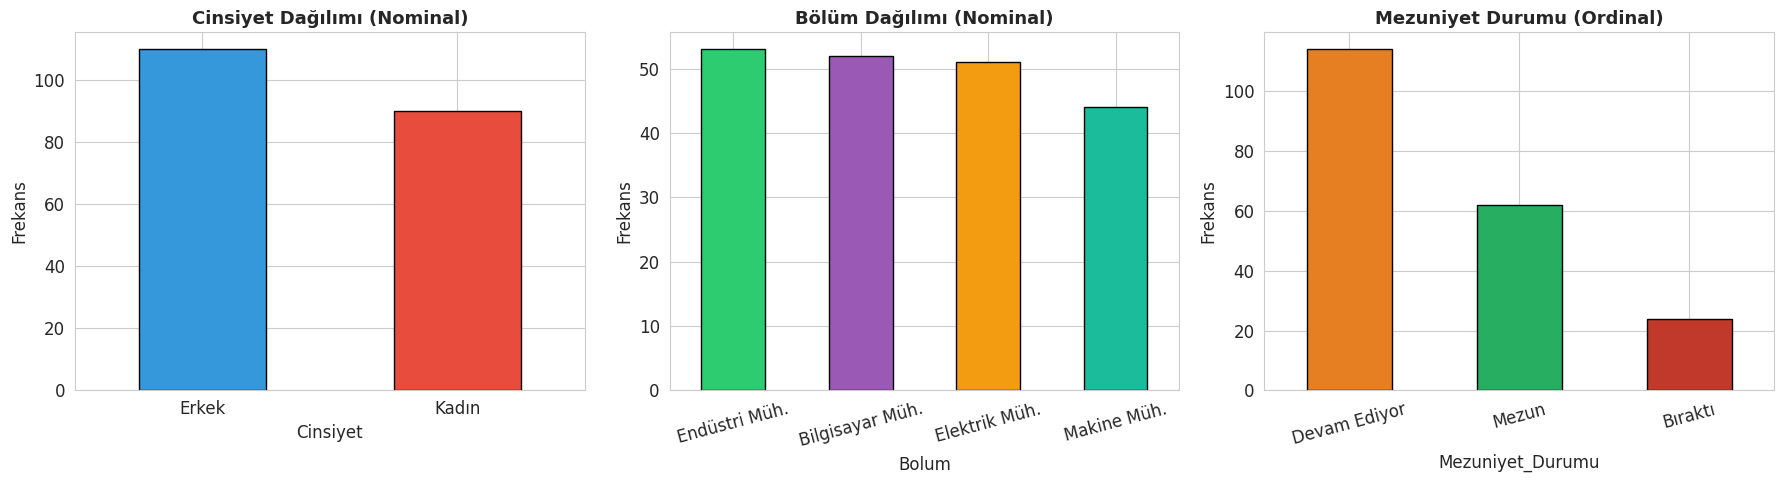

In [ ]:
# Kategorik değişkenlerin dağılımını görselleştirelim
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cinsiyet dağılımı
renk_paleti = ['#3498db', '#e74c3c']
veri['Cinsiyet'].value_counts().plot(kind='bar', ax=axes[0], color=renk_paleti, edgecolor='black')
axes[0].set_title('Cinsiyet Dağılımı (Nominal)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Frekans')
axes[0].tick_params(axis='x', rotation=0)

# Bölüm dağılımı
renk_paleti2 = ['#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']
veri['Bolum'].value_counts().plot(kind='bar', ax=axes[1], color=renk_paleti2, edgecolor='black')
axes[1].set_title('Bölüm Dağılımı (Nominal)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Frekans')
axes[1].tick_params(axis='x', rotation=15)
# Dr. Buket TOPTAŞ Bandirma Onyedi Eylül Üniversitesi

# Mezuniyet durumu (Ordinal)
renk_paleti3 = ['#e67e22', '#27ae60', '#c0392b']
sira = ['Devam Ediyor', 'Mezun', 'Bıraktı']
veri['Mezuniyet_Durumu'].value_counts().reindex(sira).plot(kind='bar', ax=axes[2], color=renk_paleti3, edgecolor='black')
axes[2].set_title('Mezuniyet Durumu (Ordinal)', fontweight='bold', fontsize=13)
axes[2].set_ylabel('Frekans')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

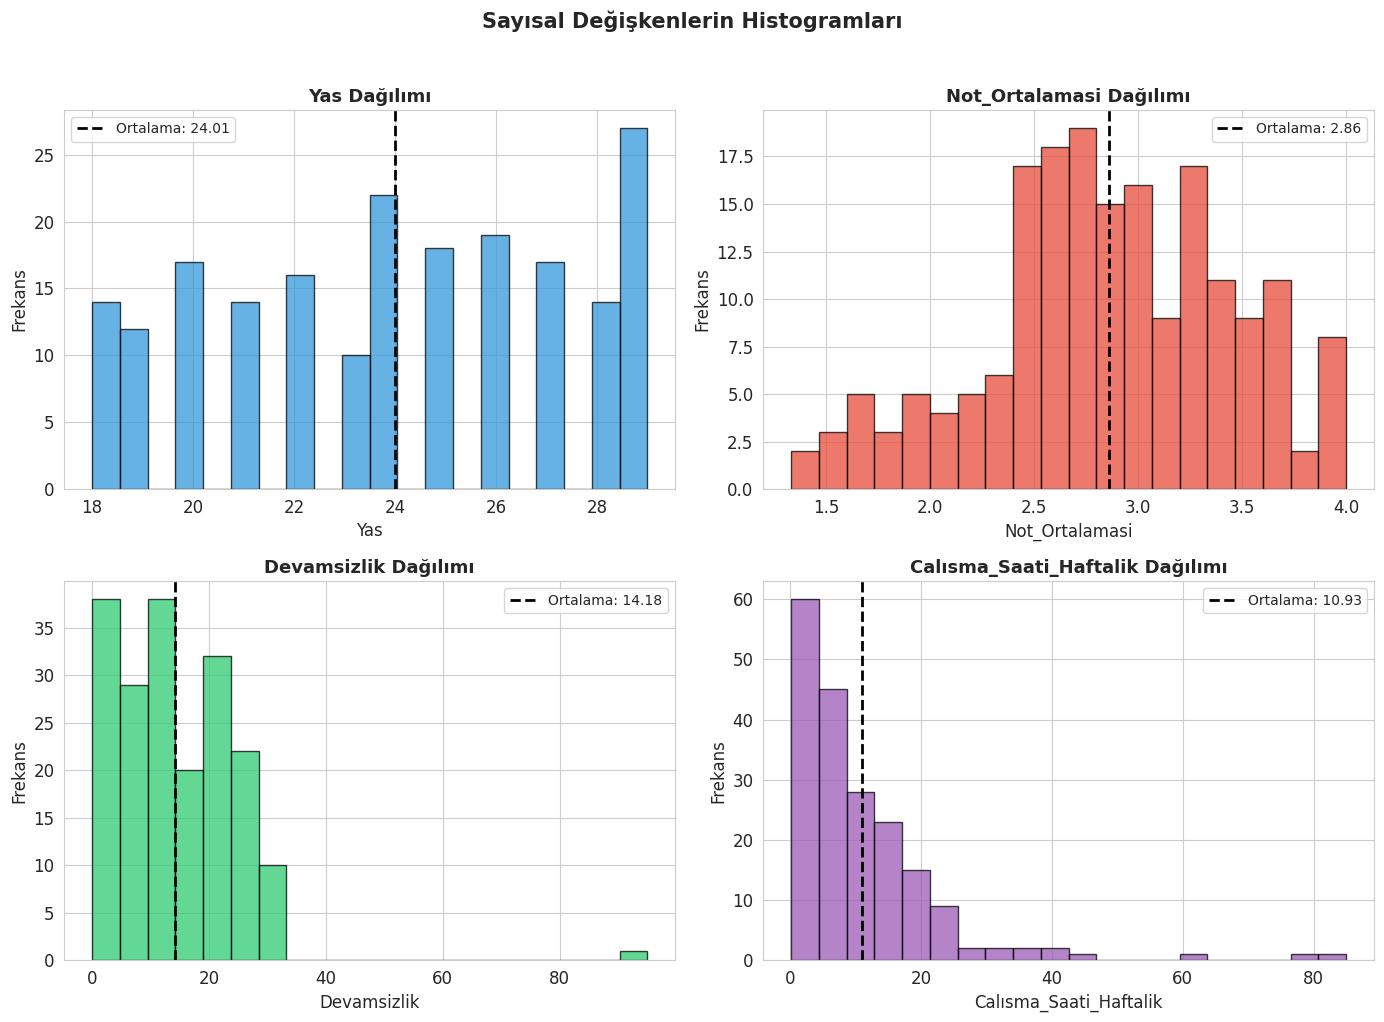

In [ ]:
# Sayısal değişkenlerin dağılımını görselleştirelim
sayisal_sutunlar = ['Yas', 'Not_Ortalamasi', 'Devamsizlik', 'Calısma_Saati_Haftalik']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
renkler = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
# Dr. Buket TOPTAŞ Bandirma Onyedi Eylül Üniversitesi

for idx, (sutun, renk) in enumerate(zip(sayisal_sutunlar, renkler)):
    ax = axes[idx // 2][idx % 2]
    veri[sutun].dropna().hist(bins=20, ax=ax, color=renk, edgecolor='black', alpha=0.75)
    ax.set_title(f'{sutun} Dağılımı', fontweight='bold', fontsize=13)
    ax.set_xlabel(sutun)
    ax.set_ylabel('Frekans')
    ax.axvline(veri[sutun].mean(), color='black', linestyle='--', linewidth=2, label=f'Ortalama: {veri[sutun].mean():.2f}')
    ax.legend(fontsize=10)

plt.suptitle('Sayısal Değişkenlerin Histogramları', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. 📌 Eksik Veri ve Aykırı Veri

Gerçek dünyada veri setleri neredeyse hiçbir zaman mükemmel değildir. İki büyük sorun karşımıza çıkar:

### 3.1 Eksik Veri (Missing Data)

**Eksik veri**, bir gözlemde bir veya daha fazla özelliğin kaydedilmemiş olmasıdır.

**Neden oluşur?**
- Sensör arızası
- Anket sorusunun boş bırakılması
- Veri aktarım hatası
- İnsan hatası

**Eksik veri türleri:**
- **MCAR (Missing Completely At Random):** Tamamen rastgele eksik. Eksiklik hiçbir değişkenle ilişkili değil.
- **MAR (Missing At Random):** Diğer değişkenlerle ilişkili. Örneğin, gelir bilgisini yüksek gelirli kişiler daha az paylaşıyor olabilir.
- **MNAR (Missing Not At Random):** Eksiklik, kaybolan değerin kendisiyle ilişkili.
# Dr. Buket TOPTAŞ Bandirma Onyedi Eylül Üniversitesi


In [ ]:
# Eksik veri analizi
print('EKSİK VERİ ANALİZİ')
print('=' * 60)

eksik_ozet = pd.DataFrame({
    'Eksik Sayısı': veri.isnull().sum(),
    'Eksik Oranı (%)': (veri.isnull().sum() / len(veri) * 100).round(2),
    'Dolu Sayısı': veri.notnull().sum()
})
# Dr. Buket TOPTAŞ Bandirma Onyedi Eylül Üniversitesi

# Sadece eksik değeri olanları gösterelim
eksik_ozet_filtreli = eksik_ozet[eksik_ozet['Eksik Sayısı'] > 0].sort_values('Eksik Sayısı', ascending=False)
print(eksik_ozet_filtreli)
print(f'\nToplam eksik hücre: {veri.isnull().sum().sum()}')
print(f'Toplam hücre sayısı: {veri.shape[0] * veri.shape[1]}')
print(f'Genel eksik oran: %{(veri.isnull().sum().sum() / (veri.shape[0] * veri.shape[1]) * 100):.2f}')

EKSİK VERİ ANALİZİ
                        Eksik Sayısı  Eksik Oranı (%)  Dolu Sayısı
Not_Ortalamasi                    15              7.5          185
Devamsizlik                       10              5.0          190
Calısma_Saati_Haftalik             8              4.0          192

Toplam eksik hücre: 33
Toplam hücre sayısı: 1800
Genel eksik oran: %1.83


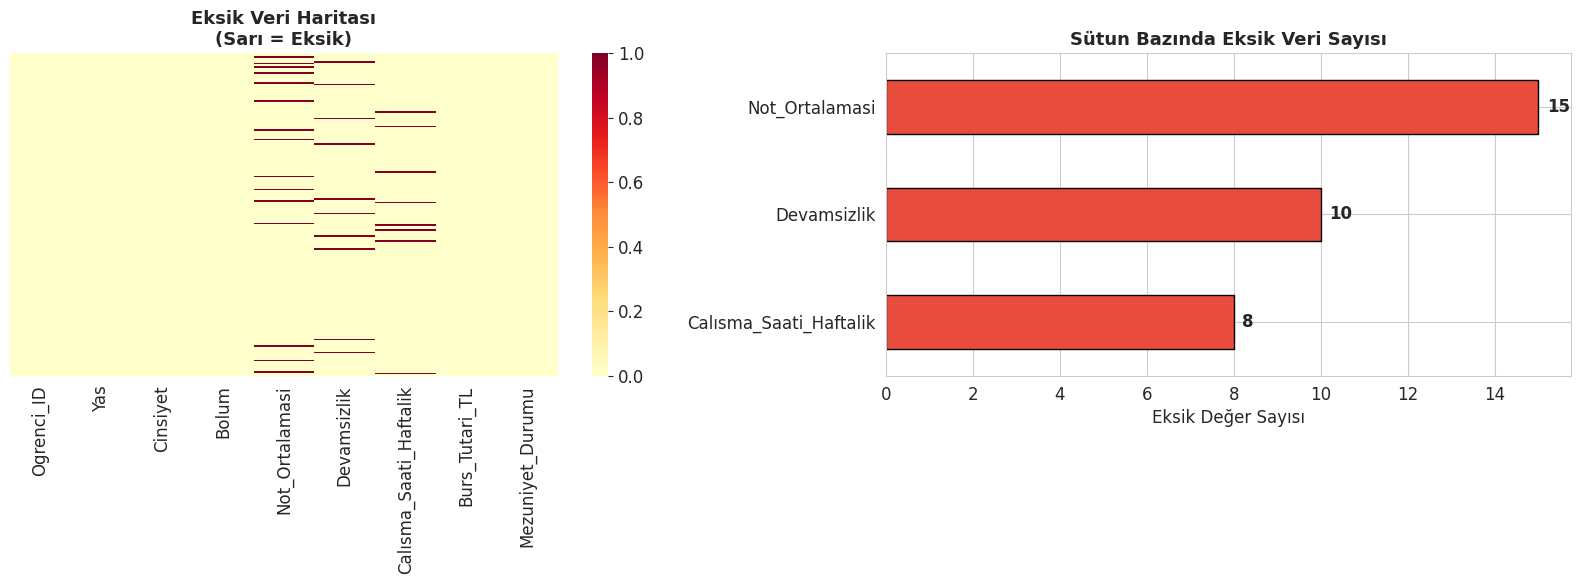

In [11]:
# Eksik veri haritası (heatmap)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Eksik veri haritası
sns.heatmap(veri.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Eksik Veri Haritası\n(Sarı = Eksik)', fontweight='bold', fontsize=13)

# Sağ: Eksik veri bar grafiği
eksik_sutunlar = veri.isnull().sum()
eksik_sutunlar = eksik_sutunlar[eksik_sutunlar > 0].sort_values(ascending=True)
eksik_sutunlar.plot(kind='barh', color='#e74c3c', edgecolor='black', ax=axes[1])
axes[1].set_title('Sütun Bazında Eksik Veri Sayısı', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Eksik Değer Sayısı')

for i, v in enumerate(eksik_sutunlar.values):
    axes[1].text(v + 0.2, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
# Eksik veri ile başa çıkma yöntemleri
print('EKSİK VERİ İLE BAŞA ÇIKMA YÖNTEMLERİ')
print('=' * 60)

# Yöntem 1: Silme
print('\n📍 Yöntem 1: Satır Silme (Listwise Deletion)')
veri_silme = veri.dropna()
print(f'   Orijinal satır sayısı : {len(veri)}')
print(f'   Silme sonrası         : {len(veri_silme)}')
print(f'   Kaybedilen veri       : {len(veri) - len(veri_silme)} satır (%{((len(veri) - len(veri_silme)) / len(veri) * 100):.1f})')

# Yöntem 2: Ortalama ile doldurma
print('\n📍 Yöntem 2: Ortalama ile Doldurma (Mean Imputation)')
veri_ortalama = veri.copy()
for col in ['Not_Ortalamasi', 'Devamsizlik', 'Calısma_Saati_Haftalik']:
    ortalama_deger = veri_ortalama[col].mean()
    veri_ortalama[col].fillna(ortalama_deger, inplace=True)
    print(f'   {col}: eksikler {ortalama_deger:.2f} ile dolduruldu')

# Yöntem 3: Medyan ile doldurma
print('\n📍 Yöntem 3: Medyan ile Doldurma (Median Imputation)')
veri_medyan = veri.copy()
for col in ['Not_Ortalamasi', 'Devamsizlik', 'Calısma_Saati_Haftalik']:
    medyan_deger = veri_medyan[col].median()
    veri_medyan[col].fillna(medyan_deger, inplace=True)
    print(f'   {col}: eksikler {medyan_deger:.2f} ile dolduruldu')

# Yöntem 4: Scikit-learn SimpleImputer
print('\n📍 Yöntem 4: Scikit-learn SimpleImputer Kullanımı')
imputer = SimpleImputer(strategy='median')
sayisal_kolonlar = ['Not_Ortalamasi', 'Devamsizlik', 'Calısma_Saati_Haftalik']
veri_imputed = veri.copy()
veri_imputed[sayisal_kolonlar] = imputer.fit_transform(veri[sayisal_kolonlar])
print(f'   Eksik kalan değer sayısı: {veri_imputed[sayisal_kolonlar].isnull().sum().sum()}')

print('\n💡 İpucu: Aykırı değerler varsa MEDYAN kullanmak daha güvenlidir.')
print('   Çünkü ortalama aykırı değerlerden etkilenirken, medyan etkilenmez.')

EKSİK VERİ İLE BAŞA ÇIKMA YÖNTEMLERİ

📍 Yöntem 1: Satır Silme (Listwise Deletion)
   Orijinal satır sayısı : 200
   Silme sonrası         : 167
   Kaybedilen veri       : 33 satır (%16.5)

📍 Yöntem 2: Ortalama ile Doldurma (Mean Imputation)
   Not_Ortalamasi: eksikler 2.86 ile dolduruldu
   Devamsizlik: eksikler 14.18 ile dolduruldu
   Calısma_Saati_Haftalik: eksikler 10.93 ile dolduruldu

📍 Yöntem 3: Medyan ile Doldurma (Median Imputation)
   Not_Ortalamasi: eksikler 2.83 ile dolduruldu
   Devamsizlik: eksikler 14.00 ile dolduruldu
   Calısma_Saati_Haftalik: eksikler 7.80 ile dolduruldu

📍 Yöntem 4: Scikit-learn SimpleImputer Kullanımı
   Eksik kalan değer sayısı: 0

💡 İpucu: Aykırı değerler varsa MEDYAN kullanmak daha güvenlidir.
   Çünkü ortalama aykırı değerlerden etkilenirken, medyan etkilenmez.


### 3.2 Aykırı Veri (Outlier)

**Aykırı değer**, veri kümesindeki diğer gözlemlerden belirgin şekilde farklı olan değerdir.

**Neden oluşur?**
- Ölçüm hatası
- Veri giriş hatası  
- Gerçek ama nadir bir durum (örneğin: bir CEO'nun maaşı)
- Farklı bir popülasyondan gelen veri

**Tespit yöntemleri:**
1. **IQR Yöntemi:** Q1 - 1.5×IQR altı veya Q3 + 1.5×IQR üstü aykırıdır.
2. **Z-Skoru Yöntemi:** |Z| > 3 olan değerler aykırıdır.
3. **Görsel Yöntemler:** Box Plot, Scatter Plot

In [ ]:
# Aykırı değer analizi - IQR Yöntemi
print('AYKIRI DEĞER ANALİZİ (IQR YÖNTEMİ)')
print('=' * 70)

def aykiri_deger_bul_iqr(seri, sutun_adi):
    """IQR yöntemiyle aykırı değerleri tespit eder."""
    seri_temiz = seri.dropna()
    Q1 = seri_temiz.quantile(0.25)
    Q3 = seri_temiz.quantile(0.75)
    IQR = Q3 - Q1
    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR
    aykirilar = seri_temiz[(seri_temiz < alt_sinir) | (seri_temiz > ust_sinir)]
# Dr. Buket TOPTAŞ Bandirma Onyedi Eylül Üniversitesi

    print(f'\n  📍 {sutun_adi}:')
    print(f'     Q1 = {Q1:.2f} | Q3 = {Q3:.2f} | IQR = {IQR:.2f}')
    print(f'     Alt Sınır = {alt_sinir:.2f} | Üst Sınır = {ust_sinir:.2f}')
    print(f'     Aykırı değer sayısı: {len(aykirilar)}')
    if len(aykirilar) > 0:
        print(f'     Aykırı değerler: {sorted(aykirilar.values)}')
    return aykirilar

aykiri_sonuclar = {}
for col in ['Yas', 'Not_Ortalamasi', 'Devamsizlik', 'Calısma_Saati_Haftalik']:
    aykiri_sonuclar[col] = aykiri_deger_bul_iqr(veri_imputed[col], col)

AYKIRI DEĞER ANALİZİ (IQR YÖNTEMİ)

  📍 Yas:
     Q1 = 21.00 | Q3 = 27.00 | IQR = 6.00
     Alt Sınır = 12.00 | Üst Sınır = 36.00
     Aykırı değer sayısı: 0

  📍 Not_Ortalamasi:
     Q1 = 2.54 | Q3 = 3.27 | IQR = 0.73
     Alt Sınır = 1.44 | Üst Sınır = 4.38
     Aykırı değer sayısı: 2
     Aykırı değerler: [np.float64(1.33), np.float64(1.43)]

  📍 Devamsizlik:
     Q1 = 6.00 | Q3 = 21.00 | IQR = 15.00
     Alt Sınır = -16.50 | Üst Sınır = 43.50
     Aykırı değer sayısı: 1
     Aykırı değerler: [np.float64(95.0)]

  📍 Calısma_Saati_Haftalik:
     Q1 = 3.77 | Q3 = 14.57 | IQR = 10.80
     Alt Sınır = -12.42 | Üst Sınır = 30.77
     Aykırı değer sayısı: 10
     Aykırı değerler: [np.float64(32.0), np.float64(32.9), np.float64(36.7), np.float64(37.1), np.float64(38.6), np.float64(42.2), np.float64(44.9), np.float64(60.7), np.float64(78.0), np.float64(85.0)]


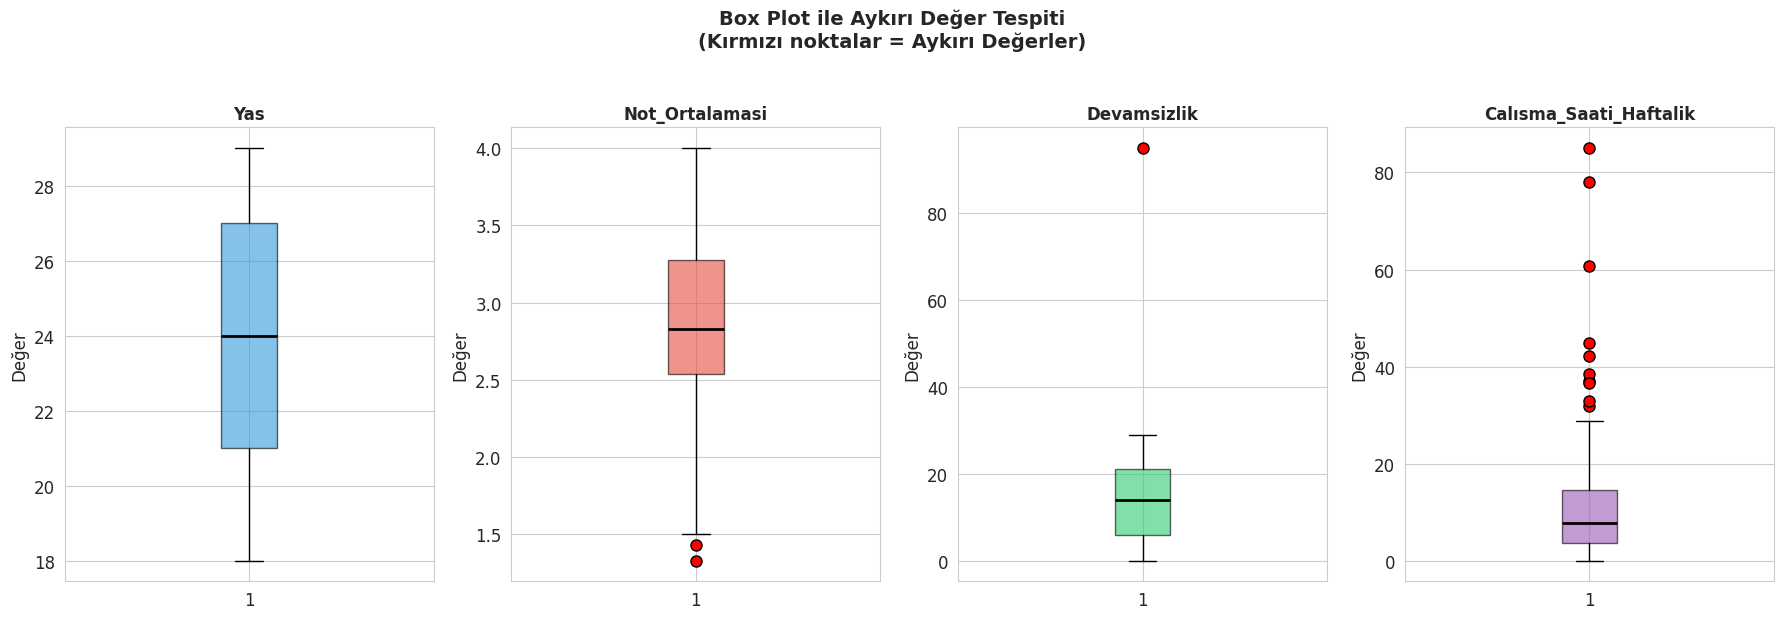

In [ ]:
# Aykırı değer görselleştirmesi - Box Plot
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
renkler_bp = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for idx, (col, renk) in enumerate(zip(['Yas', 'Not_Ortalamasi', 'Devamsizlik', 'Calısma_Saati_Haftalik'], renkler_bp)):
    bp = axes[idx].boxplot(veri_imputed[col].dropna(), patch_artist=True,
                           boxprops=dict(facecolor=renk, alpha=0.6),
                           medianprops=dict(color='black', linewidth=2),
                           flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
    axes[idx].set_title(f'{col}', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Değer')

plt.suptitle('Box Plot ile Aykırı Değer Tespiti\n(Kırmızı noktalar = Aykırı Değerler)',
             fontweight='bold', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# Z-Skoru ile aykırı değer tespiti
print('AYKIRI DEĞER ANALİZİ (Z-SKORU YÖNTEMİ)')
print('=' * 70)
print('Kural: |Z| > 3 olan değerler aykırıdır.\n')

for col in ['Not_Ortalamasi', 'Devamsizlik', 'Calısma_Saati_Haftalik']:
    z_scores = np.abs(stats.zscore(veri_imputed[col].dropna()))
    aykiri_z = (z_scores > 3).sum()
    print(f'  📍 {col}: {aykiri_z} aykırı değer (|Z| > 3)')
    if aykiri_z > 0:
        aykiri_indeksler = np.where(z_scores > 3)[0]
        print(f'     Değerler: {veri_imputed[col].dropna().iloc[aykiri_indeksler].values}')
        print(f'     Z-Skorları: {z_scores[aykiri_indeksler].round(2)}')
        # Dr. Buket TOPTAŞ Bandirma Onyedi Eylül Üniversitesi


AYKIRI DEĞER ANALİZİ (Z-SKORU YÖNTEMİ)
Kural: |Z| > 3 olan değerler aykırıdır.

  📍 Not_Ortalamasi: 0 aykırı değer (|Z| > 3)
  📍 Devamsizlik: 1 aykırı değer (|Z| > 3)
     Değerler: [95.]
     Z-Skorları: [7.92]
  📍 Calısma_Saati_Haftalik: 3 aykırı değer (|Z| > 3)
     Değerler: [85.  78.  60.7]
     Z-Skorları: [6.42 5.82 4.32]


In [ ]:
# Aykırı değer ile başa çıkma yöntemleri
print('AYKIRI DEĞER İLE BAŞA ÇIKMA YÖNTEMLERİ')
print('=' * 60)

# Yöntem 1: Silme
print('\n📍 Yöntem 1: Aykırı Değerleri Silme')
Q1 = veri_imputed['Calısma_Saati_Haftalik'].quantile(0.25)
Q3 = veri_imputed['Calısma_Saati_Haftalik'].quantile(0.75)
IQR = Q3 - Q1
filtre = (veri_imputed['Calısma_Saati_Haftalik'] >= Q1 - 1.5*IQR) & (veri_imputed['Calısma_Saati_Haftalik'] <= Q3 + 1.5*IQR)
print(f'   Silme öncesi: {len(veri_imputed)} satır')
print(f'   Silme sonrası: {filtre.sum()} satır')

# Yöntem 2: Kırpma (Capping / Winsorizing)
print('\n📍 Yöntem 2: Kırpma (Winsorizing)')
print('   Alt ve üst sınır değerleriyle değiştirilir.')
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR
veri_kirpilmis = veri_imputed['Calısma_Saati_Haftalik'].clip(lower=alt_sinir, upper=ust_sinir)
print(f'   Alt sınır: {alt_sinir:.2f}, Üst sınır: {ust_sinir:.2f}')
print(f'   Kırpma öncesi max: {veri_imputed["Calısma_Saati_Haftalik"].max():.1f}')
print(f'   Kırpma sonrası max: {veri_kirpilmis.max():.1f}')

# Yöntem 3: Dönüştürme
print('\n📍 Yöntem 3: Log Dönüşümü')
print('   Sağa çarpık verilerde aykırı değerlerin etkisini azaltır.')
print(f'   Orijinal std sapma  : {veri_imputed["Calısma_Saati_Haftalik"].std():.2f}')
print(f'   Log dönüşüm sonrası: {np.log1p(veri_imputed["Calısma_Saati_Haftalik"]).std():.2f}')
# Dr. Buket TOPTAŞ Bandirma Onyedi Eylül Üniversitesi


AYKIRI DEĞER İLE BAŞA ÇIKMA YÖNTEMLERİ

📍 Yöntem 1: Aykırı Değerleri Silme
   Silme öncesi: 200 satır
   Silme sonrası: 190 satır

📍 Yöntem 2: Kırpma (Winsorizing)
   Alt ve üst sınır değerleriyle değiştirilir.
   Alt sınır: -12.42, Üst sınır: 30.77
   Kırpma öncesi max: 85.0
   Kırpma sonrası max: 30.8

📍 Yöntem 3: Log Dönüşümü
   Sağa çarpık verilerde aykırı değerlerin etkisini azaltır.
   Orijinal std sapma  : 11.58
   Log dönüşüm sonrası: 0.85


---
## 4. 📌 Temel İstatistiksel Ölçümler

Veriyi anlamanın ilk adımı, temel istatistiksel ölçümleri hesaplamaktır.

### Merkezi Eğilim Ölçüleri
Verinin "ortasını" tarif eder:

| Ölçü | Tanım | Ne Zaman Kullanılır? |
|------|-------|---------------------|
| **Ortalama (Mean)** | Tüm değerlerin toplamı / değer sayısı | Normal dağılımlı verilerde |
| **Medyan (Median)** | Sıralanmış verinin ortasındaki değer | Çarpık verilerde, aykırı değer varsa |
| **Mod (Mode)** | En sık tekrar eden değer | Kategorik verilerde |

### Yayılım Ölçüleri
Verinin ne kadar "dağıldığını" gösterir:

| Ölçü | Tanım |
|------|-------|
| **Varyans** | Ortalamadan sapmaların karelerinin ortalaması |
| **Standart Sapma** | Varyansın karekökü (orijinal birimde) |
| **Aralık (Range)** | Max - Min |
| **IQR** | Q3 - Q1 (çeyrekler arası aralık) |
# Dr. Buket TOPTAŞ Bandirma Onyedi Eylül Üniversitesi


In [15]:
# Kapsamlı istatistiksel özet
print('KAPSAMLI İSTATİSTİKSEL ÖZET')
print('=' * 90)

sayisal_kolonlar_analiz = ['Yas', 'Not_Ortalamasi', 'Devamsizlik', 'Calısma_Saati_Haftalik']

istatistik_tablosu = pd.DataFrame(index=sayisal_kolonlar_analiz)

for col in sayisal_kolonlar_analiz:
    seri = veri_imputed[col]
    istatistik_tablosu.loc[col, 'Ortalama'] = seri.mean()
    istatistik_tablosu.loc[col, 'Medyan'] = seri.median()
    istatistik_tablosu.loc[col, 'Mod'] = seri.mode().iloc[0] if not seri.mode().empty else np.nan
    istatistik_tablosu.loc[col, 'Std Sapma'] = seri.std()
    istatistik_tablosu.loc[col, 'Varyans'] = seri.var()
    istatistik_tablosu.loc[col, 'Min'] = seri.min()
    istatistik_tablosu.loc[col, 'Q1 (25%)'] = seri.quantile(0.25)
    istatistik_tablosu.loc[col, 'Q3 (75%)'] = seri.quantile(0.75)
    istatistik_tablosu.loc[col, 'Max'] = seri.max()
    istatistik_tablosu.loc[col, 'IQR'] = seri.quantile(0.75) - seri.quantile(0.25)
    istatistik_tablosu.loc[col, 'Aralık'] = seri.max() - seri.min()

print(istatistik_tablosu.round(3).to_string())

KAPSAMLI İSTATİSTİKSEL ÖZET
                        Ortalama  Medyan    Mod  Std Sapma  Varyans    Min  Q1 (25%)  Q3 (75%)   Max     IQR  Aralık
Yas                       24.010   24.00  29.00      3.489   12.171  18.00    21.000    27.000  29.0   6.000   11.00
Not_Ortalamasi             2.856    2.83   2.83      0.570    0.325   1.33     2.538     3.272   4.0   0.735    2.67
Devamsizlik               14.170   14.00  14.00     10.227  104.594   0.00     6.000    21.000  95.0  15.000   95.00
Calısma_Saati_Haftalik    10.808    7.80   7.80     11.577  134.037   0.10     3.775    14.575  85.0  10.800   84.90


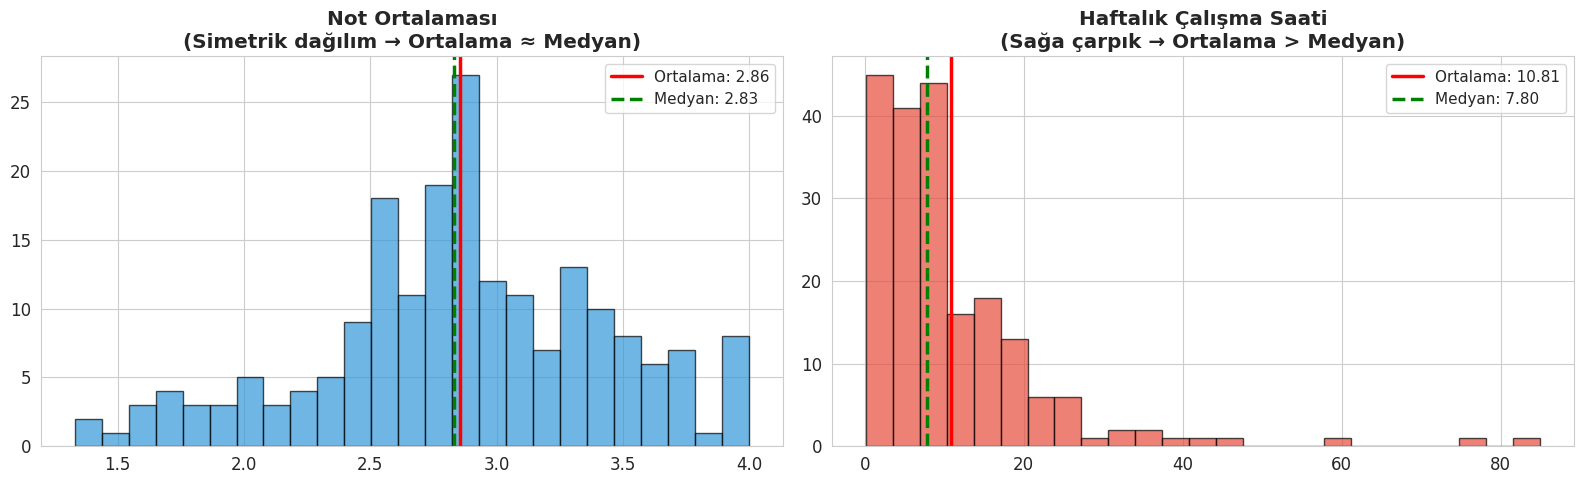

💡 YORUM: Simetrik dağılımda ortalama ve medyan birbirine yakındır.
   Çarpık dağılımda ise ortalama, aykırı değerlerin olduğu tarafa kayar.
   Bu durumda medyan daha güvenilir bir merkezi eğilim ölçüsüdür.


In [ ]:
# Ortalama vs Medyan karşılaştırması - Aykırı değerin etkisini görelim
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Normal dağılıma yakın veri: Not Ortalaması
ax1 = axes[0]
veri_imputed['Not_Ortalamasi'].hist(bins=25, ax=ax1, color='#3498db', edgecolor='black', alpha=0.7)
ort_not = veri_imputed['Not_Ortalamasi'].mean()
med_not = veri_imputed['Not_Ortalamasi'].median()
ax1.axvline(ort_not, color='red', linewidth=2.5, linestyle='-', label=f'Ortalama: {ort_not:.2f}')
ax1.axvline(med_not, color='green', linewidth=2.5, linestyle='--', label=f'Medyan: {med_not:.2f}')
ax1.set_title('Not Ortalaması\n(Simetrik dağılım → Ortalama ≈ Medyan)', fontweight='bold')
ax1.legend(fontsize=11)

# Çarpık veri: Çalışma Saati
ax2 = axes[1]
veri_imputed['Calısma_Saati_Haftalik'].hist(bins=25, ax=ax2, color='#e74c3c', edgecolor='black', alpha=0.7)
ort_cal = veri_imputed['Calısma_Saati_Haftalik'].mean()
med_cal = veri_imputed['Calısma_Saati_Haftalik'].median()
ax2.axvline(ort_cal, color='red', linewidth=2.5, linestyle='-', label=f'Ortalama: {ort_cal:.2f}')
ax2.axvline(med_cal, color='green', linewidth=2.5, linestyle='--', label=f'Medyan: {med_cal:.2f}')
ax2.set_title('Haftalık Çalışma Saati\n(Sağa çarpık → Ortalama > Medyan)', fontweight='bold')
ax2.legend(fontsize=11)
# Dr. Buket TOPTAŞ Bandirma Onyedi Eylül Üniversitesi

plt.tight_layout()
plt.show()

print('💡 YORUM: Simetrik dağılımda ortalama ve medyan birbirine yakındır.')
print('   Çarpık dağılımda ise ortalama, aykırı değerlerin olduğu tarafa kayar.')
print('   Bu durumda medyan daha güvenilir bir merkezi eğilim ölçüsüdür.')

---
## 5. 📌 Çarpıklık (Skewness) ve Basıklık (Kurtosis)

### 5.1 Çarpıklık (Skewness)

Verinin dağılımının **simetrik olup olmadığını** ölçer.

| Çarpıklık Değeri | Anlam | Görsel |
|-------------------|-------|--------|
| **= 0** | Tam simetrik (Normal dağılım) | Ortalama = Medyan = Mod |
| **> 0 (Pozitif)** | Sağa çarpık, kuyruk sağda uzun | Mod < Medyan < Ortalama |
| **< 0 (Negatif)** | Sola çarpık, kuyruk solda uzun | Ortalama < Medyan < Mod |

**Genel kural:**
- |Çarpıklık| < 0.5 → Yaklaşık simetrik
- 0.5 ≤ |Çarpıklık| < 1 → Orta düzey çarpık
- |Çarpıklık| ≥ 1 → Yüksek düzey çarpık

### 5.2 Basıklık (Kurtosis)

Dağılımın **kuyruk kalınlığını ve tepe sivriğini** ölçer. Normal dağılıma göre karşılaştırma yapılır.    # Dr. Buket TOPTAŞ Bandirma Onyedi Eylül Üniversitesi


| Basıklık Türü | Değer (Fazlalık) | Anlam |
|---------------|-------------------|-------|
| **Mesokurtik** | ≈ 0 | Normal dağılıma benzer |
| **Leptokurtik** | > 0 | Sivri tepe, kalın kuyruklar (uç değerler daha olası) |
| **Platikurtik** | < 0 | Yassı tepe, ince kuyruklar (uç değerler daha az olası) |

In [17]:
# Çarpıklık ve Basıklık hesaplama
print('ÇARPIKLIK VE BASIKLIK ANALİZİ')
print('=' * 80)

for col in sayisal_kolonlar_analiz:
    seri = veri_imputed[col]
    carpiklik = seri.skew()
    basiklik = seri.kurtosis()  # Fisher's (Fazlalık basıklığı: Normal = 0)

    # Çarpıklık yorumu
    if abs(carpiklik) < 0.5:
        carpiklik_yorum = 'Yaklaşık simetrik ✅'
    elif abs(carpiklik) < 1:
        carpiklik_yorum = 'Orta düzey çarpık ⚠️'
    else:
        carpiklik_yorum = 'Yüksek düzey çarpık ❌'

    yon = 'Sağa çarpık (pozitif)' if carpiklik > 0 else 'Sola çarpık (negatif)' if carpiklik < 0 else 'Simetrik'

    # Basıklık yorumu
    if abs(basiklik) < 0.5:
        basiklik_yorum = 'Mesokurtik (Normal benzeri)'
    elif basiklik > 0:
        basiklik_yorum = 'Leptokurtik (Sivri tepe, kalın kuyruk)'
    else:
        basiklik_yorum = 'Platikurtik (Yassı tepe, ince kuyruk)'

    print(f'\n  📍 {col}')
    print(f'     Çarpıklık = {carpiklik:>7.3f} → {yon} → {carpiklik_yorum}')
    print(f'     Basıklık  = {basiklik:>7.3f} → {basiklik_yorum}')

ÇARPIKLIK VE BASIKLIK ANALİZİ

  📍 Yas
     Çarpıklık =  -0.155 → Sola çarpık (negatif) → Yaklaşık simetrik ✅
     Basıklık  =  -1.172 → Platikurtik (Yassı tepe, ince kuyruk)

  📍 Not_Ortalamasi
     Çarpıklık =  -0.247 → Sola çarpık (negatif) → Yaklaşık simetrik ✅
     Basıklık  =  -0.051 → Mesokurtik (Normal benzeri)

  📍 Devamsizlik
     Çarpıklık =   2.478 → Sağa çarpık (pozitif) → Yüksek düzey çarpık ❌
     Basıklık  =  18.075 → Leptokurtik (Sivri tepe, kalın kuyruk)

  📍 Calısma_Saati_Haftalik
     Çarpıklık =   3.201 → Sağa çarpık (pozitif) → Yüksek düzey çarpık ❌
     Basıklık  =  14.839 → Leptokurtik (Sivri tepe, kalın kuyruk)


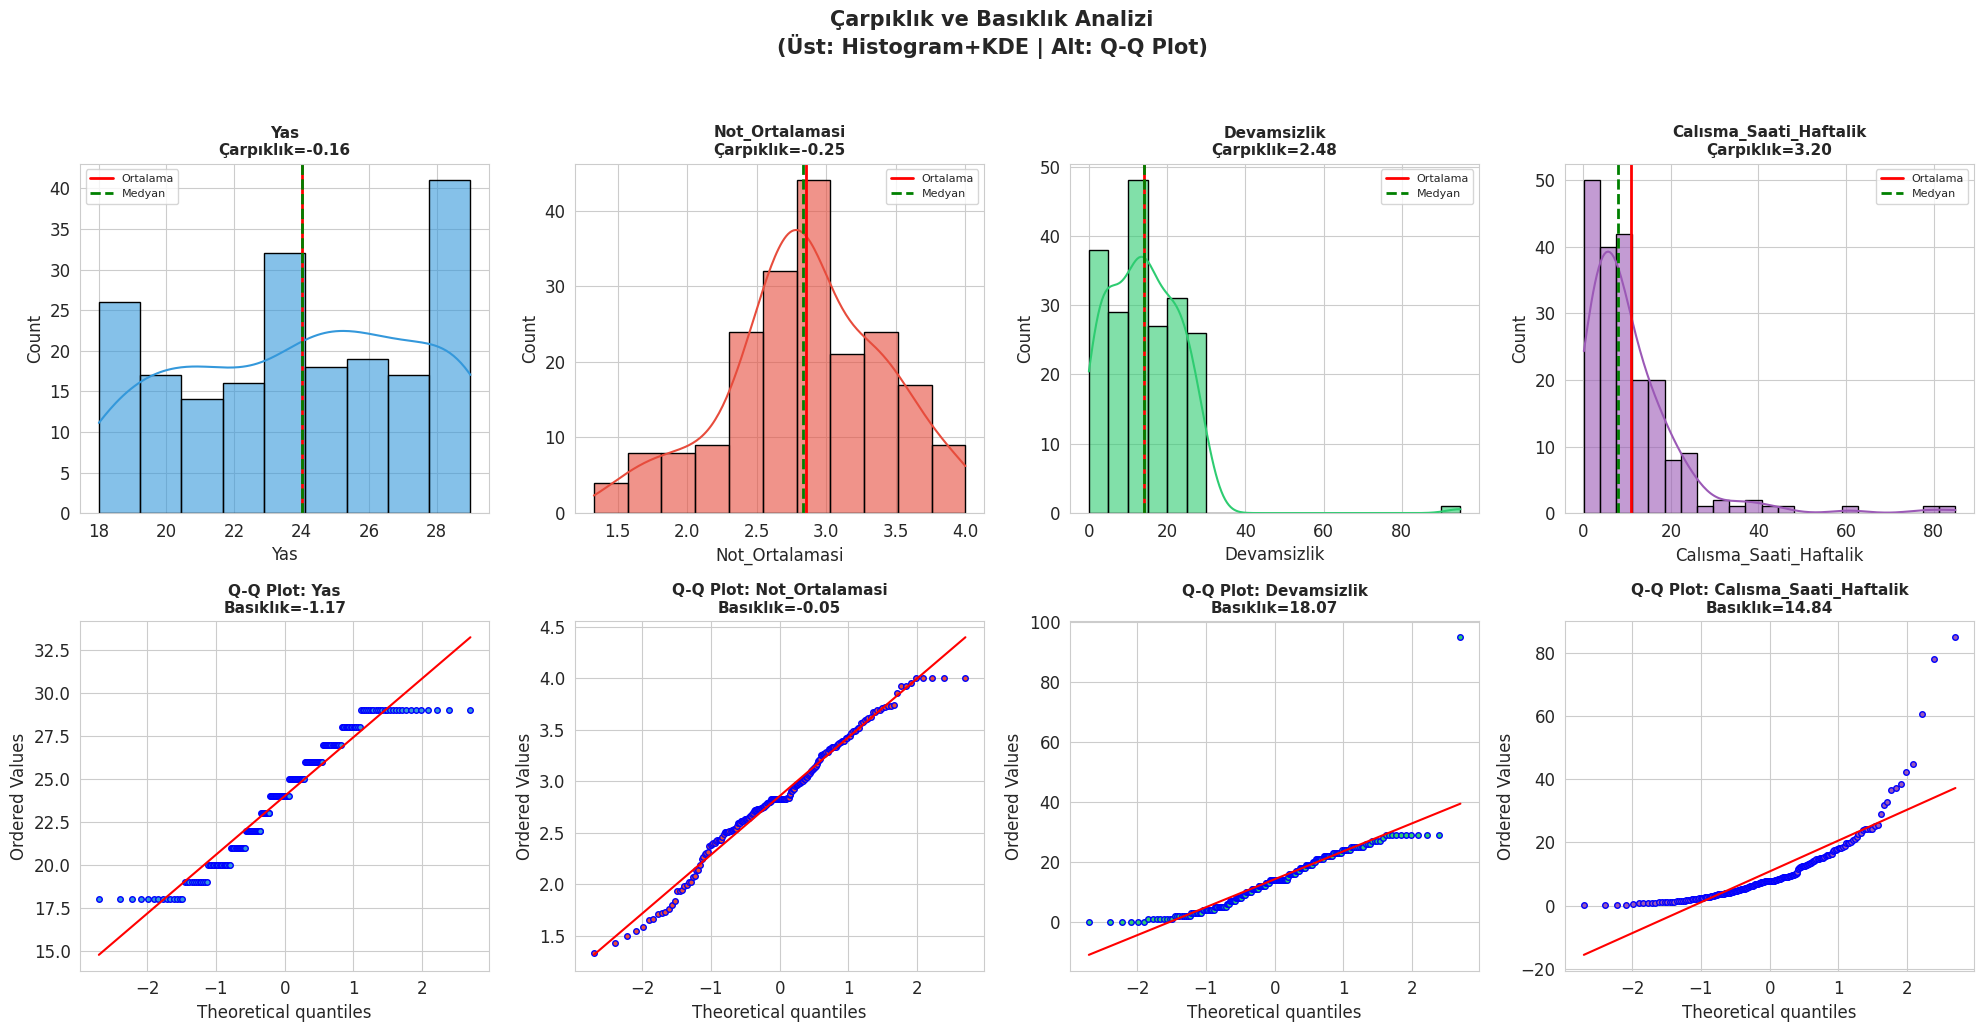

💡 Q-Q Plot YORUMU:
   Noktalar kırmızı çizgiye ne kadar yakınsa, veri o kadar normal dağılıma yakındır.
   Uçlardaki sapmalar → kuyruk kalınlığı hakkında bilgi verir.


In [ ]:
# Çarpıklık ve Basıklık Görselleştirmesi
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
renkler_dist = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for idx, (col, renk) in enumerate(zip(sayisal_kolonlar_analiz, renkler_dist)):
    seri = veri_imputed[col]
    carpiklik = seri.skew()
    basiklik = seri.kurtosis()

    # Üst satır: Histogram + KDE
    ax_top = axes[0][idx]
    sns.histplot(seri, kde=True, ax=ax_top, color=renk, edgecolor='black', alpha=0.6)
    ax_top.axvline(seri.mean(), color='red', linewidth=2, linestyle='-', label='Ortalama')
    ax_top.axvline(seri.median(), color='green', linewidth=2, linestyle='--', label='Medyan')
    ax_top.set_title(f'{col}\nÇarpıklık={carpiklik:.2f}', fontweight='bold', fontsize=11)
    ax_top.legend(fontsize=8)

    # Alt satır: QQ Plot (Normallik testi)
    ax_bot = axes[1][idx]
    stats.probplot(seri, dist='norm', plot=ax_bot)
    ax_bot.set_title(f'Q-Q Plot: {col}\nBasıklık={basiklik:.2f}', fontweight='bold', fontsize=11)
    ax_bot.get_lines()[0].set_markerfacecolor(renk)
    ax_bot.get_lines()[0].set_markersize(4)

plt.suptitle('Çarpıklık ve Basıklık Analizi\n(Üst: Histogram+KDE | Alt: Q-Q Plot)',
             fontweight='bold', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

print('💡 Q-Q Plot YORUMU:')
print('   Noktalar kırmızı çizgiye ne kadar yakınsa, veri o kadar normal dağılıma yakındır.')
print('   Uçlardaki sapmalar → kuyruk kalınlığı hakkında bilgi verir.')

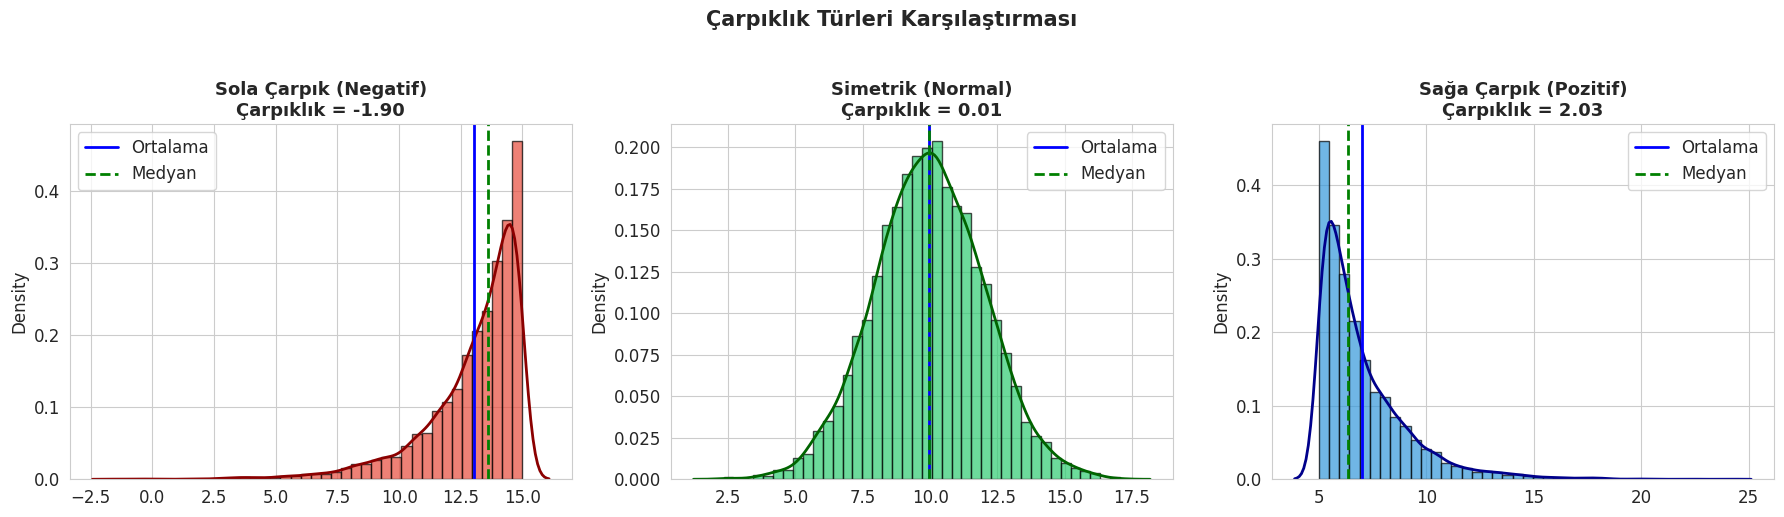

💡 YORUM:
   • Sola çarpık: Ortalama < Medyan (kuyruk solda uzanır)
   • Simetrik   : Ortalama ≈ Medyan (iki taraf dengeli)
   • Sağa çarpık: Ortalama > Medyan (kuyruk sağda uzanır)


In [ ]:
# Çarpıklık türlerini yapay veriyle görselleştirme
np.random.seed(42)
n = 5000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sola çarpık (Negatif)
sola_carpik = -np.random.exponential(2, n) + 15
axes[0].hist(sola_carpik, bins=40, color='#e74c3c', edgecolor='black', alpha=0.7, density=True)
sns.kdeplot(sola_carpik, ax=axes[0], color='darkred', linewidth=2)
axes[0].set_title(f'Sola Çarpık (Negatif)\nÇarpıklık = {pd.Series(sola_carpik).skew():.2f}',
                  fontweight='bold', fontsize=13)
axes[0].axvline(np.mean(sola_carpik), color='blue', linewidth=2, linestyle='-', label='Ortalama')
axes[0].axvline(np.median(sola_carpik), color='green', linewidth=2, linestyle='--', label='Medyan')
axes[0].legend()

# Simetrik (Normal)
simetrik = np.random.normal(10, 2, n)
axes[1].hist(simetrik, bins=40, color='#2ecc71', edgecolor='black', alpha=0.7, density=True)
sns.kdeplot(simetrik, ax=axes[1], color='darkgreen', linewidth=2)
axes[1].set_title(f'Simetrik (Normal)\nÇarpıklık = {pd.Series(simetrik).skew():.2f}',
                  fontweight='bold', fontsize=13)
axes[1].axvline(np.mean(simetrik), color='blue', linewidth=2, linestyle='-', label='Ortalama')
axes[1].axvline(np.median(simetrik), color='green', linewidth=2, linestyle='--', label='Medyan')
axes[1].legend()

# Sağa çarpık (Pozitif)
saga_carpik = np.random.exponential(2, n) + 5
axes[2].hist(saga_carpik, bins=40, color='#3498db', edgecolor='black', alpha=0.7, density=True)
sns.kdeplot(saga_carpik, ax=axes[2], color='darkblue', linewidth=2)
axes[2].set_title(f'Sağa Çarpık (Pozitif)\nÇarpıklık = {pd.Series(saga_carpik).skew():.2f}',
                  fontweight='bold', fontsize=13)
axes[2].axvline(np.mean(saga_carpik), color='blue', linewidth=2, linestyle='-', label='Ortalama')
axes[2].axvline(np.median(saga_carpik), color='green', linewidth=2, linestyle='--', label='Medyan')
axes[2].legend()

plt.suptitle('Çarpıklık Türleri Karşılaştırması', fontweight='bold', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

print('💡 YORUM:')
print('   • Sola çarpık: Ortalama < Medyan (kuyruk solda uzanır)')
print('   • Simetrik   : Ortalama ≈ Medyan (iki taraf dengeli)')
print('   • Sağa çarpık: Ortalama > Medyan (kuyruk sağda uzanır)')

---
## 6. 📌 Dağılım Grafikleri ve Yorumlanması

Verideki ilişkileri ve yapıyı görsel olarak keşfetmenin en etkili yolu grafiklerdir.

| Grafik Türü | Ne Gösterir? | Ne Zaman Kullanılır? |
|-------------|-------------|---------------------|
| Histogram | Tek değişkenin frekans dağılımı | Dağılım şeklini görmek için |
| KDE Plot | Düzleştirilmiş yoğunluk tahmini | Histogramın yumuşatılmış versiyonu |
| Box Plot | Medyan, çeyrekler, aykırı değerler | Özet istatistik + aykırı değer tespiti |
| Violin Plot | Box Plot + KDE birleşimi | Dağılım şekli + özet istatistik |
| Scatter Plot | İki değişken arası ilişki | Korelasyon tespiti |
| Pair Plot | Tüm çift değişken ilişkileri | Keşifsel analiz |
| Heatmap | Korelasyon matrisi | Değişkenler arası ilişki gücü |

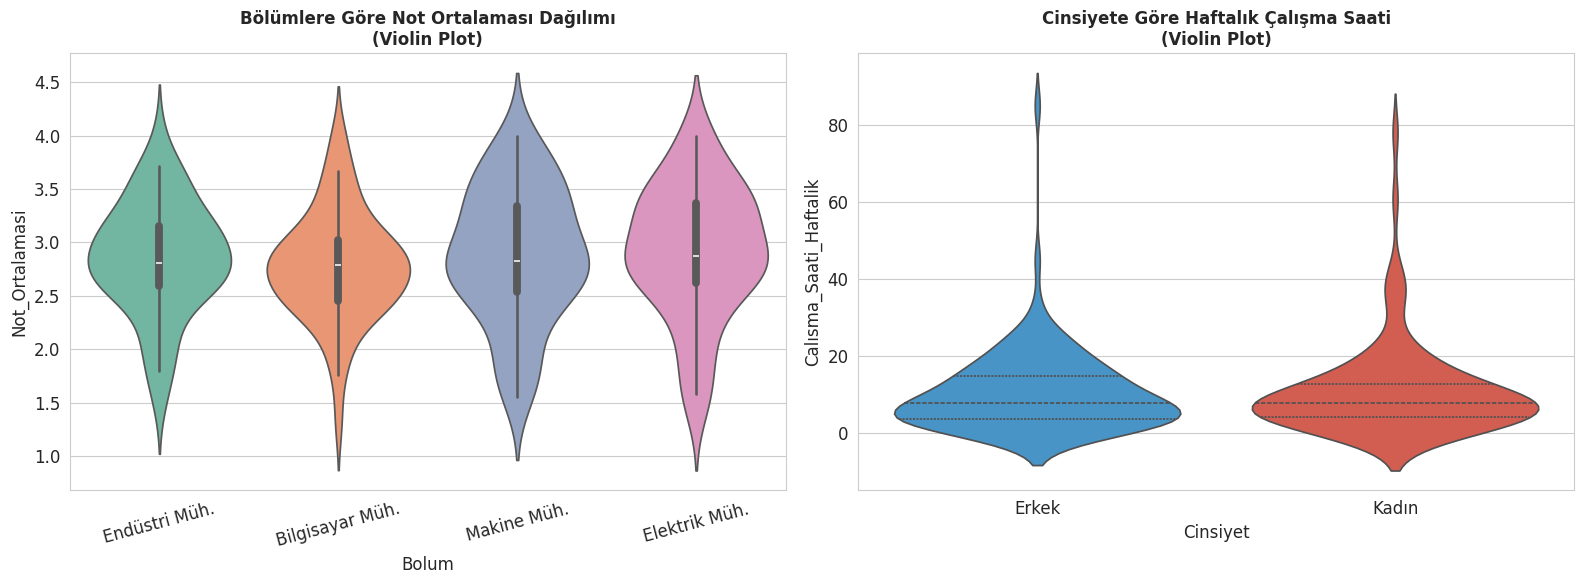

💡 Violin Plot YORUMU:
   Kalın bölgeler → o aralıkta daha fazla veri noktası var (yüksek yoğunluk).
   İnce bölgeler  → o aralıkta az veri noktası var (düşük yoğunluk).
   İçteki kutu    → Box plot özeti (medyan, çeyrekler).


In [ ]:
# 6.1 Violin Plot - Box Plot ve KDE'nin birleşimi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bölüm bazında Not Ortalaması
sns.violinplot(data=veri_imputed, x='Bolum', y='Not_Ortalamasi',
               palette='Set2', inner='box', ax=axes[0])
axes[0].set_title('Bölümlere Göre Not Ortalaması Dağılımı\n(Violin Plot)', fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)

# Cinsiyet bazında Çalışma Saati
sns.violinplot(data=veri_imputed, x='Cinsiyet', y='Calısma_Saati_Haftalik',
               palette=['#3498db', '#e74c3c'], inner='quartile', ax=axes[1])
axes[1].set_title('Cinsiyete Göre Haftalık Çalışma Saati\n(Violin Plot)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print('💡 Violin Plot YORUMU:')
print('   Kalın bölgeler → o aralıkta daha fazla veri noktası var (yüksek yoğunluk).')
print('   İnce bölgeler  → o aralıkta az veri noktası var (düşük yoğunluk).')
print('   İçteki kutu    → Box plot özeti (medyan, çeyrekler).')

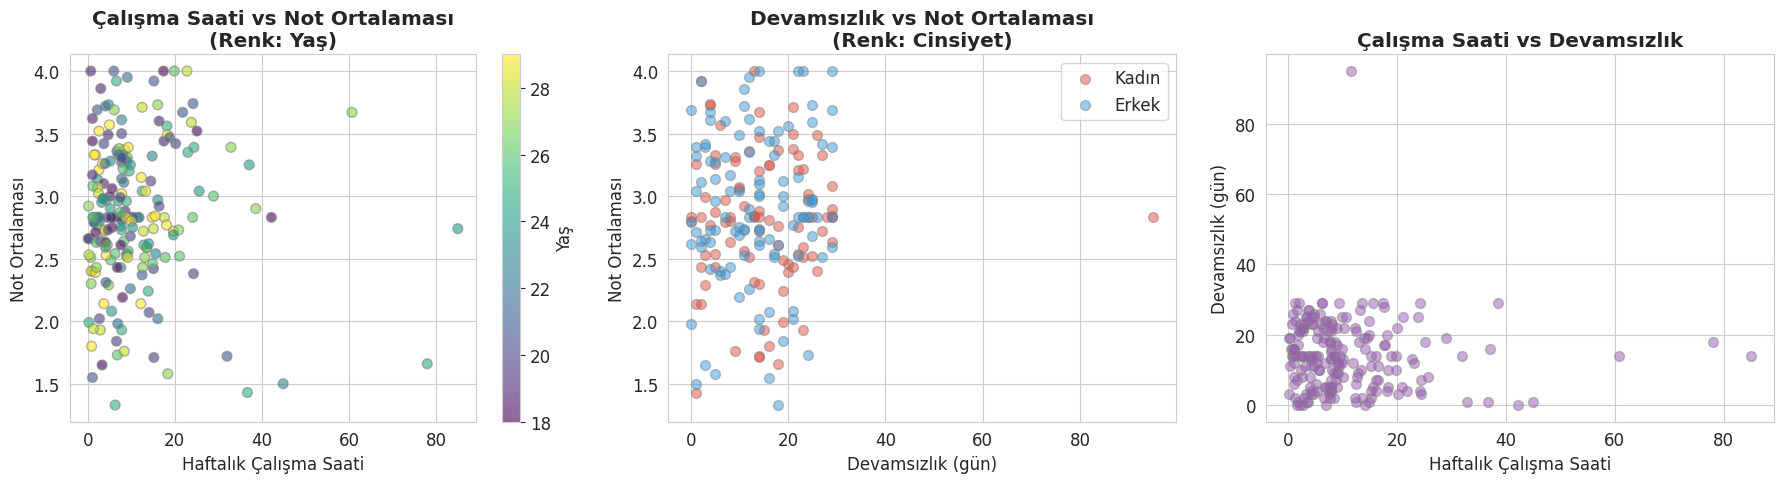

In [ ]:
# 6.2 Scatter Plot - İki değişken arası ilişki
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Not vs Çalışma Saati
ax1 = axes[0]
scatter1 = ax1.scatter(veri_imputed['Calısma_Saati_Haftalik'], veri_imputed['Not_Ortalamasi'],
                       c=veri_imputed['Yas'], cmap='viridis', alpha=0.6, edgecolor='gray', s=50)
plt.colorbar(scatter1, ax=ax1, label='Yaş')
ax1.set_xlabel('Haftalık Çalışma Saati')
ax1.set_ylabel('Not Ortalaması')
ax1.set_title('Çalışma Saati vs Not Ortalaması\n(Renk: Yaş)', fontweight='bold')

# Not vs Devamsızlık
ax2 = axes[1]
renk_map = {'Kadın': '#e74c3c', 'Erkek': '#3498db'}
for cinsiyet, renk in renk_map.items():
    mask = veri_imputed['Cinsiyet'] == cinsiyet
    ax2.scatter(veri_imputed.loc[mask, 'Devamsizlik'], veri_imputed.loc[mask, 'Not_Ortalamasi'],
               color=renk, alpha=0.5, label=cinsiyet, edgecolor='gray', s=50)
ax2.set_xlabel('Devamsızlık (gün)')
ax2.set_ylabel('Not Ortalaması')
ax2.set_title('Devamsızlık vs Not Ortalaması\n(Renk: Cinsiyet)', fontweight='bold')
ax2.legend()

# Çalışma Saati vs Devamsızlık
ax3 = axes[2]
ax3.scatter(veri_imputed['Calısma_Saati_Haftalik'], veri_imputed['Devamsizlik'],
           color='#9b59b6', alpha=0.5, edgecolor='gray', s=50)
ax3.set_xlabel('Haftalık Çalışma Saati')
ax3.set_ylabel('Devamsızlık (gün)')
ax3.set_title('Çalışma Saati vs Devamsızlık', fontweight='bold')

plt.tight_layout()
plt.show()

KORELASYON ANALİZİ
Pearson korelasyon katsayısı: -1 ile +1 arasında değer alır.
  +1 → Mükemmel pozitif ilişki (biri artarsa diğeri de artar)
   0 → İlişki yok
  -1 → Mükemmel negatif ilişki (biri artarsa diğeri azalır)



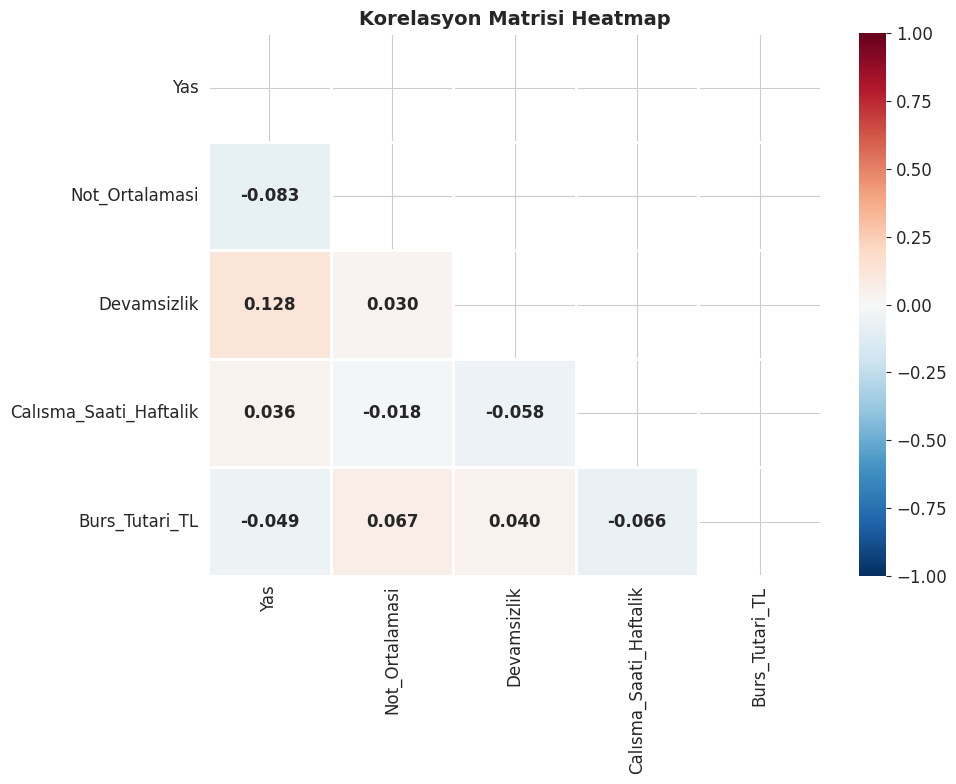

💡 YORUM:
   Koyu kırmızı → Güçlü pozitif korelasyon
   Koyu mavi    → Güçlü negatif korelasyon
   Beyaz/açık   → Zayıf veya sıfır korelasyon


In [ ]:
# 6.3 Korelasyon Matrisi ve Heatmap
print('KORELASYON ANALİZİ')
print('=' * 60)
print('Pearson korelasyon katsayısı: -1 ile +1 arasında değer alır.')
print('  +1 → Mükemmel pozitif ilişki (biri artarsa diğeri de artar)')
print('   0 → İlişki yok')
print('  -1 → Mükemmel negatif ilişki (biri artarsa diğeri azalır)\n')

korelasyon = veri_imputed[sayisal_kolonlar_analiz + ['Burs_Tutari_TL']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(korelasyon, dtype=bool))  # Üst üçgeni gizle
sns.heatmap(korelasyon, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.3f', linewidths=1, ax=ax, vmin=-1, vmax=1,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('Korelasyon Matrisi Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print('💡 YORUM:')
print('   Koyu kırmızı → Güçlü pozitif korelasyon')
print('   Koyu mavi    → Güçlü negatif korelasyon')
print('   Beyaz/açık   → Zayıf veya sıfır korelasyon')

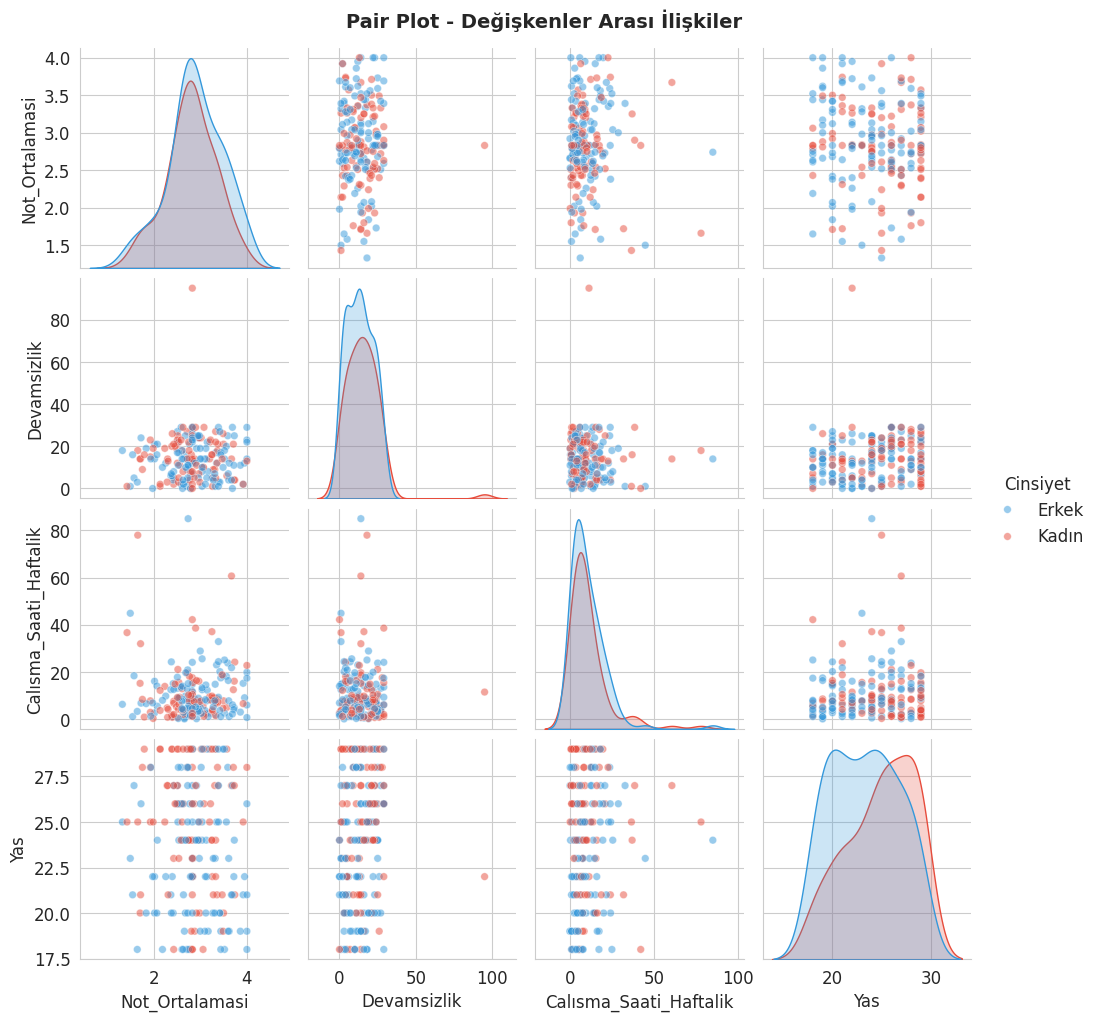

💡 Pair Plot YORUMU:
   Köşegen  → Her değişkenin kendi dağılımı (KDE)
   Üst/Alt  → İki değişken arasındaki scatter plot
   Renk     → Gruplar arasındaki fark görülür


In [ ]:
# 6.4 Pair Plot - Tüm çift değişken ilişkileri
pair_veri = veri_imputed[['Not_Ortalamasi', 'Devamsizlik', 'Calısma_Saati_Haftalik', 'Yas', 'Cinsiyet']].copy()

g = sns.pairplot(pair_veri, hue='Cinsiyet', palette={'Kadın': '#e74c3c', 'Erkek': '#3498db'},
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30},
                 height=2.5)
g.fig.suptitle('Pair Plot - Değişkenler Arası İlişkiler', fontweight='bold', fontsize=14, y=1.02)
plt.show()

print('💡 Pair Plot YORUMU:')
print('   Köşegen  → Her değişkenin kendi dağılımı (KDE)')
print('   Üst/Alt  → İki değişken arasındaki scatter plot')
print('   Renk     → Gruplar arasındaki fark görülür')

---
## 7. 📌 Veri Biliminde Kullanılan Kütüphaneler ve Avantajları

### Temel Kütüphaneler

| Kütüphane | Alan | Temel İşlevi | Avantajı |
|-----------|------|-------------|----------|
| **NumPy** | Hesaplama | Çok boyutlu dizi işlemleri | C ile yazılmış, çok hızlı |
| **Pandas** | Veri İşleme | Tablo (DataFrame) işlemleri | Excel benzeri ama çok daha güçlü |
| **Matplotlib** | Görselleştirme | Temel grafikler | Tam kontrol, her şeyi özelleştir |
| **Seaborn** | Görselleştirme | İstatistiksel grafikler | Az kodla güzel grafikler |
| **Scipy** | Bilimsel Hesaplama | İstatistik testleri, optimizasyon | Geniş bilimsel fonksiyon seti |
| **Scikit-learn** | Makine Öğrenmesi | Sınıflandırma, kümeleme, regresyon | En popüler ML kütüphanesi |
| **Plotly** | Görselleştirme | İnteraktif grafikler | Web üzerinde etkileşimli grafikler |

In [ ]:
# NumPy vs Python list performans karşılaştırması
import time

boyut = 1_000_000

# Python list ile toplama
py_list = list(range(boyut))
baslangic = time.time()
py_toplam = sum(py_list)
py_sure = time.time() - baslangic

# NumPy array ile toplama
np_array = np.arange(boyut)
baslangic = time.time()
np_toplam = np.sum(np_array)
np_sure = time.time() - baslangic

print('NUMPY vs PYTHON LİST PERFORMANS KARŞILAŞTIRMASI')
print('=' * 55)
print(f'Eleman sayısı: {boyut:,}')
print(f'Python list süresi : {py_sure*1000:.3f} ms')
print(f'NumPy array süresi : {np_sure*1000:.3f} ms')
print(f'NumPy {py_sure/np_sure:.1f}x daha hızlı! 🚀')

NUMPY vs PYTHON LİST PERFORMANS KARŞILAŞTIRMASI
Eleman sayısı: 1,000,000
Python list süresi : 10.599 ms
NumPy array süresi : 1.047 ms
NumPy 10.1x daha hızlı! 🚀


In [ ]:
# Pandas DataFrame yetenekleri
print('PANDAS DATAFRAME YETENEKLERİ')
print('=' * 55)

# Gruplama ve Pivot
print('\n📍 Bölüm bazında Not Ortalaması (GroupBy):')
print(veri_imputed.groupby('Bolum')['Not_Ortalamasi'].agg(['mean', 'median', 'std']).round(3).to_string())

print('\n📍 Cinsiyet ve Bölüm bazında Pivot Tablo:')
pivot = veri_imputed.pivot_table(values='Not_Ortalamasi', index='Bolum',
                                  columns='Cinsiyet', aggfunc='mean').round(3)
print(pivot.to_string())

PANDAS DATAFRAME YETENEKLERİ

📍 Bölüm bazında Not Ortalaması (GroupBy):
                  mean  median    std
Bolum                                
Bilgisayar Müh.  2.780    2.79  0.510
Elektrik Müh.    2.914    2.87  0.622
Endüstri Müh.    2.852    2.81  0.531
Makine Müh.      2.880    2.83  0.627

📍 Cinsiyet ve Bölüm bazında Pivot Tablo:
Cinsiyet         Erkek  Kadın
Bolum                        
Bilgisayar Müh.  2.820  2.741
Elektrik Müh.    3.035  2.789
Endüstri Müh.    2.875  2.817
Makine Müh.      2.867  2.899


---
## 8. 📌 Scikit-learn vs TensorFlow vs PyTorch

Bu üç kütüphane farklı ihtiyaçlara cevap verir. Hangisini ne zaman kullanacağınızı bilmek çok önemlidir.

### Karşılaştırma Tablosu

| Özellik | Scikit-learn | TensorFlow | PyTorch |
|---------|-------------|------------|----------|
| **Geliştirici** | Topluluk | Google | Meta (Facebook) |
| **Ana Alan** | Klasik ML | Derin Öğrenme | Derin Öğrenme |
| **Öğrenme Eğrisi** | Kolay | Orta-Zor | Orta |
| **GPU Desteği** | Yok | Tam | Tam |
| **Prototipleme** | Çok hızlı | Orta | Hızlı |
| **Üretime Alma** | Kolay | Çok iyi (TF Serving) | İyi (TorchServe) |
| **Küçük Veri** | Mükemmel | Gereksiz | Gereksiz |
| **Büyük Veri / DL** | Yetersiz | Mükemmel | Mükemmel |
| **Araştırma** | Az tercih | Tercih edilir | En çok tercih |
| **Endüstri** | Yaygın | Çok yaygın | Giderek artıyor |

### Ne Zaman Hangisi?

```
Problemi tanımla
    │
    ├── Tablo verisi + Klasik ML (sınıflandırma, regresyon, kümeleme)
    │   └── ✅ Scikit-learn
    │
    ├── Görüntü / Metin / Ses → Derin Öğrenme gerekli
    │   ├── Akademik araştırma → ✅ PyTorch
    │   └── Ürün geliştirme   → ✅ TensorFlow
    │
    └── Veri ön işleme / Özellik mühendisliği
        └── ✅ Scikit-learn (her durumda)
```

### Veri Madenciliği Dersi İçin Tavsiye

Bu ders kapsamında **Scikit-learn** kullanacağız, çünkü:
- Klasik veri madenciliği algoritmalarını (karar ağaçları, kümeleme, birliktelik kuralları vb.) barındırır.
- Veri ön işleme araçları çok güçlüdür.
- Öğrenme eğrisi düşüktür, API tutarlıdır.
- Tüm iş akışı `fit → transform → predict` kalıbıyla çalışır.

In [ ]:
# Scikit-learn'ün tutarlı API yapısı
print('SCIKIT-LEARN API YAPISI')
print('=' * 55)
print('''
Scikit-learn'de her şey aynı kalıpla çalışır:

    1. model = Model()           → Modeli oluştur
    2. model.fit(X_train)        → Veriyi öğren
    3. model.transform(X_test)   → Dönüştür
       veya
       model.predict(X_test)     → Tahmin et

Bu tutarlılık sayesinde yeni bir algoritma öğrendiğinizde
kullanım şeklini zaten bilirsiniz!
''')

# Kısa bir örnek
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Aynı API kalıbı: Ölçekleme
scaler = StandardScaler()
X_olcekli = scaler.fit_transform(veri_imputed[['Not_Ortalamasi', 'Calısma_Saati_Haftalik']])
print(f'Ölçekleme öncesi ortalama: {veri_imputed["Not_Ortalamasi"].mean():.2f}')
print(f'Ölçekleme sonrası ortalama: {X_olcekli[:, 0].mean():.6f} (≈ 0)')

# Aynı API kalıbı: Kümeleme
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kumeler = kmeans.fit_predict(X_olcekli)
print(f'\nKümeleme sonucu: {np.unique(kumeler)} (3 küme bulundu)')

SCIKIT-LEARN API YAPISI

Scikit-learn'de her şey aynı kalıpla çalışır:

    1. model = Model()           → Modeli oluştur
    2. model.fit(X_train)        → Veriyi öğren
    3. model.transform(X_test)   → Dönüştür
       veya
       model.predict(X_test)     → Tahmin et

Bu tutarlılık sayesinde yeni bir algoritma öğrendiğinizde
kullanım şeklini zaten bilirsiniz!

Ölçekleme öncesi ortalama: 2.86
Ölçekleme sonrası ortalama: 0.000000 (≈ 0)

Kümeleme sonucu: [0 1 2] (3 küme bulundu)


---
## 9. 📌 Veri Ön İşleme (Data Preprocessing)

Veri ön işleme, ham veriyi makine öğrenmesi algoritmalarının kullanabileceği hale getirme sürecidir. Modellerin başarısının büyük kısmı burada belirlenir.

**"Çöp girerse, çöp çıkar" (Garbage In, Garbage Out)** prensibi veri biliminin temel kuralıdır.

### Veri Ön İşleme Adımları:

```
Ham Veri → Temizleme → Dönüştürme → Normalizasyon → Kodlama → Özellik Seçimi → Hazır Veri
```

### 9.1 Kategorik Verilerin Kodlanması

Makine öğrenmesi algoritmaları sayısal verilerle çalışır. Kategorik verileri sayıya çevirmeliyiz.

**Yöntemler:**
1. **Label Encoding:** Her kategoriye bir tamsayı atanır. Sıralı (ordinal) veriler için uygundur.
2. **One-Hot Encoding:** Her kategori için yeni bir sütun oluşturulur (0/1). Nominal veriler için gereklidir.

In [ ]:
# 9.1 Kategorik Verilerin Kodlanması
print('KATEGORİK VERİ KODLAMASI')
print('=' * 70)

# Label Encoding
print('\n📍 Label Encoding (Ordinal veriler için)')
le = LabelEncoder()
veri_encoded = veri_imputed.copy()

# Mezuniyet Durumu - Sıralama var
veri_encoded['Mezuniyet_Kod'] = le.fit_transform(veri_encoded['Mezuniyet_Durumu'])
print('\n  Mezuniyet Durumu → Sayısal Karşılık:')
for label, kod in zip(le.classes_, le.transform(le.classes_)):
    print(f'    {label:<15} → {kod}')

# One-Hot Encoding
print('\n📍 One-Hot Encoding (Nominal veriler için)')
one_hot = pd.get_dummies(veri_encoded['Bolum'], prefix='Bolum', dtype=int)
print('\n  Bölüm → One-Hot Encoding (ilk 5 satır):')
print(one_hot.head().to_string())

print('\n⚠️  DİKKAT: Nominal verilere Label Encoding uygulamak YANLIŞTIR!')
print('   Çünkü model, sayılar arasında "Bilgisayar Müh.(0) < Makine Müh.(2)"')
print('   gibi anlamsız bir sıralama ilişkisi kurar.')

KATEGORİK VERİ KODLAMASI

📍 Label Encoding (Ordinal veriler için)

  Mezuniyet Durumu → Sayısal Karşılık:
    Bıraktı         → 0
    Devam Ediyor    → 1
    Mezun           → 2

📍 One-Hot Encoding (Nominal veriler için)

  Bölüm → One-Hot Encoding (ilk 5 satır):
   Bolum_Bilgisayar Müh.  Bolum_Elektrik Müh.  Bolum_Endüstri Müh.  Bolum_Makine Müh.
0                      0                    0                    1                  0
1                      1                    0                    0                  0
2                      1                    0                    0                  0
3                      0                    0                    1                  0
4                      1                    0                    0                  0

⚠️  DİKKAT: Nominal verilere Label Encoding uygulamak YANLIŞTIR!
   Çünkü model, sayılar arasında "Bilgisayar Müh.(0) < Makine Müh.(2)"
   gibi anlamsız bir sıralama ilişkisi kurar.


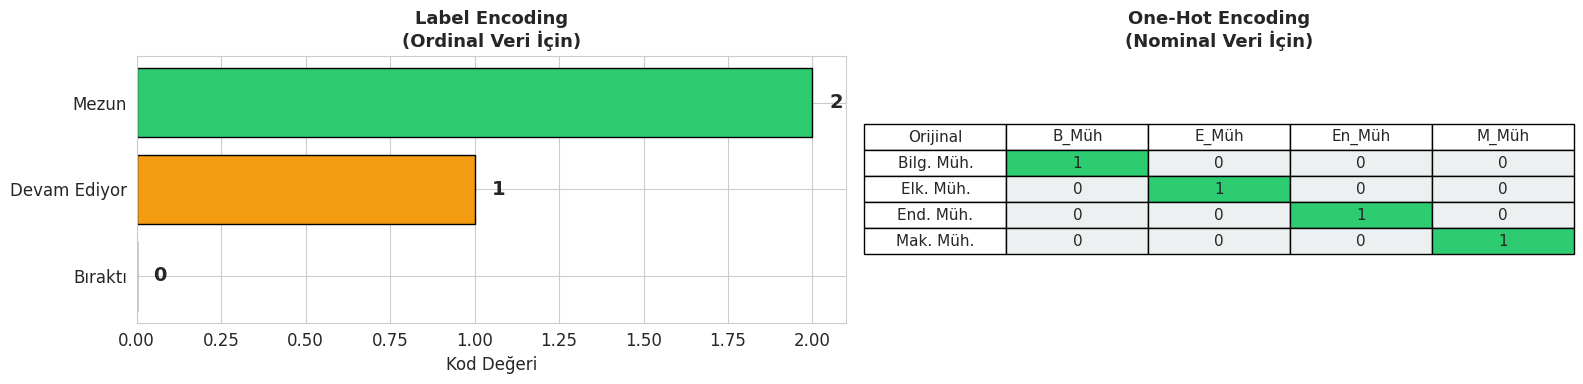

In [ ]:
# Label Encoding vs One-Hot Encoding karşılaştırması (görsel)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Label Encoding görseli
label_veri = pd.DataFrame({
    'Kategori': ['Bıraktı', 'Devam Ediyor', 'Mezun'],
    'Kod': [0, 1, 2]
})
bars = axes[0].barh(label_veri['Kategori'], label_veri['Kod'], color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
for bar, val in zip(bars, label_veri['Kod']):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold', fontsize=14)
axes[0].set_title('Label Encoding\n(Ordinal Veri İçin)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Kod Değeri')

# One-Hot Encoding görseli
oh_veri = pd.DataFrame({
    'Orijinal': ['Bilg. Müh.', 'Elk. Müh.', 'End. Müh.', 'Mak. Müh.'],
    'B_Müh': [1, 0, 0, 0],
    'E_Müh': [0, 1, 0, 0],
    'En_Müh': [0, 0, 1, 0],
    'M_Müh': [0, 0, 0, 1]
})

tablo_renkleri = [['#2ecc71' if v == 1 else '#ecf0f1' for v in row] for _, row in oh_veri[['B_Müh', 'E_Müh', 'En_Müh', 'M_Müh']].iterrows()]
table = axes[1].table(cellText=oh_veri.values, colLabels=oh_veri.columns, cellLoc='center', loc='center',
                       cellColours=[['white'] + renk_satiri for renk_satiri in tablo_renkleri])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)
axes[1].axis('off')
axes[1].set_title('One-Hot Encoding\n(Nominal Veri İçin)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

---
## 10. 📌 Veri Normalizasyonu ve Standartlaştırma

Farklı ölçekteki özellikleri karşılaştırılabilir hale getirmek gerekir. Örneğin:
- Yaş: 18-30 aralığında
- Burs: 0-7500 TL aralığında

Bu ölçek farkı, mesafe tabanlı algoritmalarda (KNN, K-Means, SVM) büyük sorun yaratır.

### Yöntemler

| Yöntem | Formül | Aralık | Ne Zaman? |
|--------|--------|--------|----------|
| **Min-Max Norm.** | (x - min) / (max - min) | [0, 1] | Dağılım bilinmiyorsa, NN için |
| **Z-Score (Standart.)** | (x - μ) / σ | ~ [-3, +3] | Normal dağılıma yakınsa |
| **Robust Scaling** | (x - medyan) / IQR | Değişken | Aykırı değer varsa |

In [ ]:
# Normalizasyon yöntemlerinin karşılaştırması
print('NORMALİZASYON YÖNTEMLERİ KARŞILAŞTIRMASI')
print('=' * 70)

ozellikler = veri_imputed[['Yas', 'Not_Ortalamasi', 'Devamsizlik', 'Calısma_Saati_Haftalik', 'Burs_Tutari_TL']].values
sutun_isimleri = ['Yas', 'Not_Ortalamasi', 'Devamsizlik', 'Calısma_Saati_Haftalik', 'Burs_Tutari_TL']

# 1. Min-Max Normalizasyon
minmax = MinMaxScaler()
veri_minmax = pd.DataFrame(minmax.fit_transform(ozellikler), columns=sutun_isimleri)

# 2. Z-Score Standartlaştırma
standard = StandardScaler()
veri_standard = pd.DataFrame(standard.fit_transform(ozellikler), columns=sutun_isimleri)

# 3. Robust Scaling
robust = RobustScaler()
veri_robust = pd.DataFrame(robust.fit_transform(ozellikler), columns=sutun_isimleri)

print('\n📍 Orijinal Veri İstatistikleri:')
print(pd.DataFrame(ozellikler, columns=sutun_isimleri).describe().round(2).loc[['min', 'mean', 'max']].to_string())

print('\n📍 Min-Max Normalizasyon Sonrası [0, 1]:')
print(veri_minmax.describe().round(3).loc[['min', 'mean', 'max']].to_string())

print('\n📍 Z-Score Standartlaştırma Sonrası (μ=0, σ=1):')
print(veri_standard.describe().round(3).loc[['min', 'mean', 'max', 'std']].to_string())

print('\n📍 Robust Scaling Sonrası (Medyan merkezli):')
print(veri_robust.describe().round(3).loc[['min', 'mean', 'max']].to_string())

NORMALİZASYON YÖNTEMLERİ KARŞILAŞTIRMASI

📍 Orijinal Veri İstatistikleri:
        Yas  Not_Ortalamasi  Devamsizlik  Calısma_Saati_Haftalik  Burs_Tutari_TL
min   18.00            1.33         0.00                    0.10             0.0
mean  24.01            2.86        14.17                   10.81          1972.5
max   29.00            4.00        95.00                   85.00          7500.0

📍 Min-Max Normalizasyon Sonrası [0, 1]:
        Yas  Not_Ortalamasi  Devamsizlik  Calısma_Saati_Haftalik  Burs_Tutari_TL
min   0.000           0.000        0.000                   0.000           0.000
mean  0.546           0.571        0.149                   0.126           0.263
max   1.000           1.000        1.000                   1.000           1.000

📍 Z-Score Standartlaştırma Sonrası (μ=0, σ=1):
        Yas  Not_Ortalamasi  Devamsizlik  Calısma_Saati_Haftalik  Burs_Tutari_TL
min  -1.727          -2.683       -1.389                  -0.927          -0.937
mean -0.000           0.000

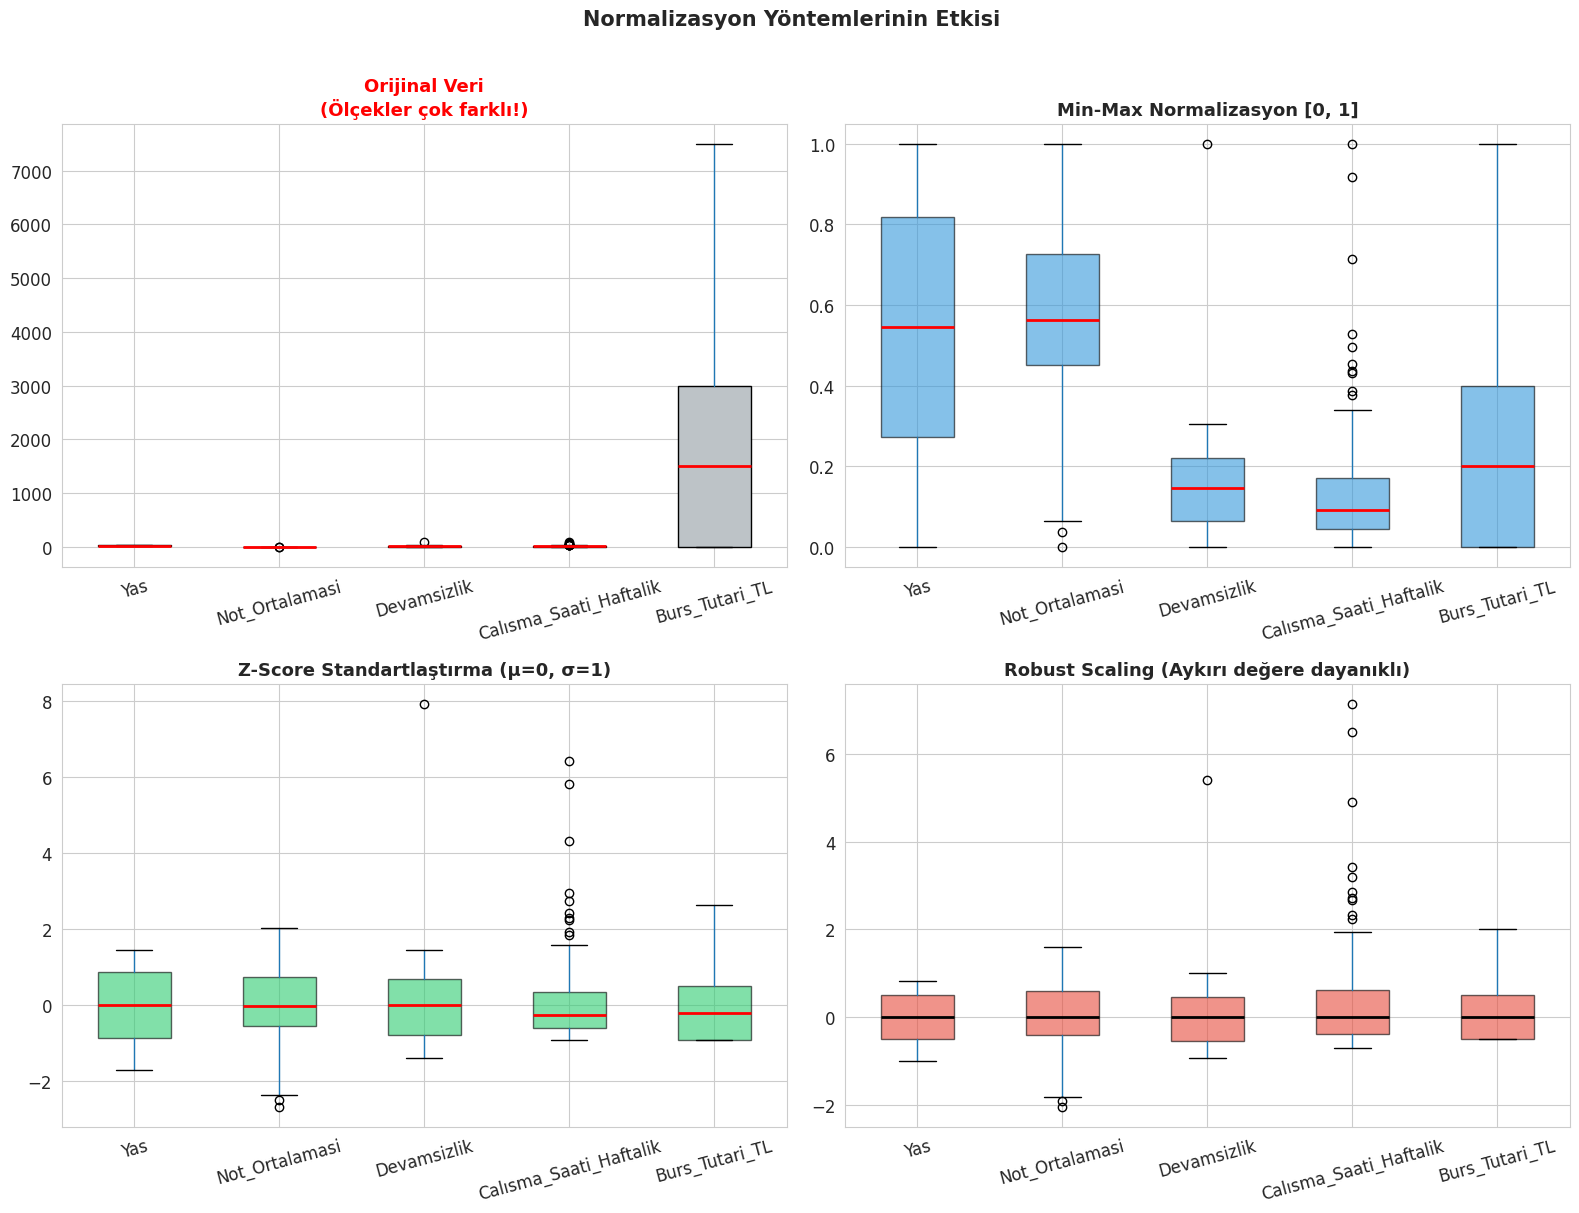

💡 YORUM:
   Orijinal veride Burs_Tutari_TL (0-7500) diğer özellikleri eziyor.
   Normalizasyon sonrası tüm özellikler aynı ölçeğe getirildi.
   Bu sayede mesafe tabanlı algoritmalar adil çalışabilir.


In [ ]:
# Normalizasyon etkisini görselleştirme
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Orijinal veri
orijinal_df = pd.DataFrame(ozellikler, columns=sutun_isimleri)
orijinal_df.boxplot(ax=axes[0][0], patch_artist=True,
                    boxprops=dict(facecolor='#bdc3c7'),
                    medianprops=dict(color='red', linewidth=2))
axes[0][0].set_title('Orijinal Veri\n(Ölçekler çok farklı!)', fontweight='bold', fontsize=13, color='red')
axes[0][0].tick_params(axis='x', rotation=15)

# Min-Max
veri_minmax.boxplot(ax=axes[0][1], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
axes[0][1].set_title('Min-Max Normalizasyon [0, 1]', fontweight='bold', fontsize=13)
axes[0][1].tick_params(axis='x', rotation=15)

# Z-Score
veri_standard.boxplot(ax=axes[1][0], patch_artist=True,
                      boxprops=dict(facecolor='#2ecc71', alpha=0.6),
                      medianprops=dict(color='red', linewidth=2))
axes[1][0].set_title('Z-Score Standartlaştırma (μ=0, σ=1)', fontweight='bold', fontsize=13)
axes[1][0].tick_params(axis='x', rotation=15)

# Robust
veri_robust.boxplot(ax=axes[1][1], patch_artist=True,
                    boxprops=dict(facecolor='#e74c3c', alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
axes[1][1].set_title('Robust Scaling (Aykırı değere dayanıklı)', fontweight='bold', fontsize=13)
axes[1][1].tick_params(axis='x', rotation=15)

plt.suptitle('Normalizasyon Yöntemlerinin Etkisi', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print('💡 YORUM:')
print('   Orijinal veride Burs_Tutari_TL (0-7500) diğer özellikleri eziyor.')
print('   Normalizasyon sonrası tüm özellikler aynı ölçeğe getirildi.')
print('   Bu sayede mesafe tabanlı algoritmalar adil çalışabilir.')

---
## 11. 📌 Özellik Seçimi (Feature Selection)

Tüm özellikler model için faydalı değildir. Gereksiz özellikler:
- Modeli yavaşlatır
- Overfitting riskini artırır
- Sonuçları kötüleştirebilir

### Özellik Seçim Yöntemleri:

1. **Varyans Eşiği (Variance Threshold):** Varyansı çok düşük olan (neredeyse sabit) özellikleri çıkarır.
2. **Tek Değişkenli İstatistik Testleri (SelectKBest):** Her özelliğin hedef değişkenle ilişkisini test eder.
3. **Korelasyon Analizi:** Yüksek korelasyonlu özelliklerden birini çıkarmak.

In [ ]:
# Özellik seçimi için Iris veri setini kullanalım (daha uygun)
print('ÖZELLİK SEÇİMİ')
print('=' * 70)

iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target

print(f'\nIris veri seti: {X_iris.shape[0]} örnek, {X_iris.shape[1]} özellik')
print(f'Özellikler: {list(X_iris.columns)}')
print(f'Hedef sınıflar: {list(iris.target_names)}\n')

# Yöntem 1: Varyans Eşiği
print('📍 Yöntem 1: Varyans Eşiği (Variance Threshold)')
print('  Her özelliğin varyansı:')
for col in X_iris.columns:
    v = X_iris[col].var()
    print(f'    {col:<25} Varyans = {v:.4f}')

vt = VarianceThreshold(threshold=0.5)
X_vt = vt.fit_transform(X_iris)
secilen_ozellikler_vt = X_iris.columns[vt.get_support()].tolist()
print(f'\n  Eşik = 0.5 → Seçilen özellikler: {secilen_ozellikler_vt}')

ÖZELLİK SEÇİMİ

Iris veri seti: 150 örnek, 4 özellik
Özellikler: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Hedef sınıflar: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

📍 Yöntem 1: Varyans Eşiği (Variance Threshold)
  Her özelliğin varyansı:
    sepal length (cm)         Varyans = 0.6857
    sepal width (cm)          Varyans = 0.1900
    petal length (cm)         Varyans = 3.1163
    petal width (cm)          Varyans = 0.5810

  Eşik = 0.5 → Seçilen özellikler: ['sepal length (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
# Yöntem 2: SelectKBest ile en iyi K özelliği seçme
print('📍 Yöntem 2: SelectKBest (F-İstatistiği ile)')
print('  Her özelliğin hedef değişkenle ilişki gücü:\n')

selector = SelectKBest(f_classif, k='all')  # Hepsini skorla
selector.fit(X_iris, y_iris)

skor_df = pd.DataFrame({
    'Özellik': X_iris.columns,
    'F-Skoru': selector.scores_,
    'p-değeri': selector.pvalues_
}).sort_values('F-Skoru', ascending=False)

print(skor_df.to_string(index=False))

# En iyi 2 özelliği seç
selector_k2 = SelectKBest(f_classif, k=2)
X_k2 = selector_k2.fit_transform(X_iris, y_iris)
secilen_k2 = X_iris.columns[selector_k2.get_support()].tolist()
print(f'\n  En iyi 2 özellik: {secilen_k2}')
print(f'  Bu 2 özellik, sınıflar arasında en büyük ayrımı sağlayanlardır.')

📍 Yöntem 2: SelectKBest (F-İstatistiği ile)
  Her özelliğin hedef değişkenle ilişki gücü:

          Özellik     F-Skoru     p-değeri
petal length (cm) 1180.161182 2.856777e-91
 petal width (cm)  960.007147 4.169446e-85
sepal length (cm)  119.264502 1.669669e-31
 sepal width (cm)   49.160040 4.492017e-17

  En iyi 2 özellik: ['petal length (cm)', 'petal width (cm)']
  Bu 2 özellik, sınıflar arasında en büyük ayrımı sağlayanlardır.


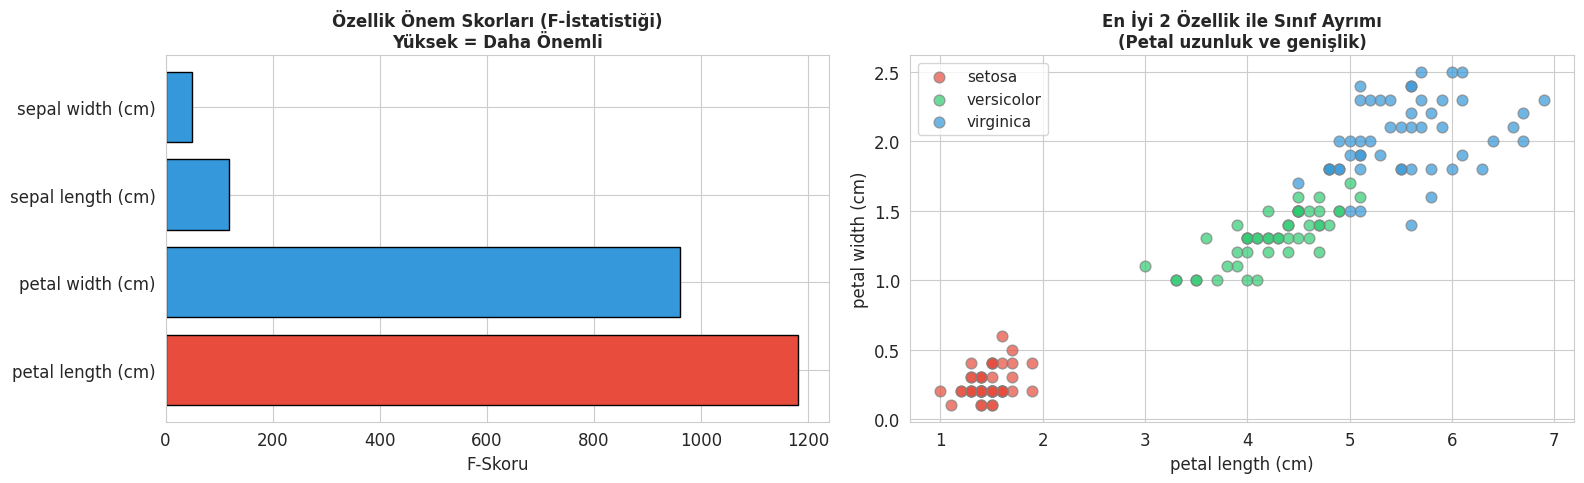

💡 YORUM: Sadece 2 özellik bile sınıfları büyük ölçüde ayırabilmektedir.
   Bu da özellik seçiminin gücünü gösterir: daha az özellik, daha hızlı model, benzer başarı.


In [ ]:
# Özellik önem skorlarını görselleştirelim
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F-Skorları
renkler_f = ['#e74c3c' if s == skor_df['F-Skoru'].max() else '#3498db' for s in skor_df['F-Skoru']]
axes[0].barh(skor_df['Özellik'], skor_df['F-Skoru'], color=renkler_f, edgecolor='black')
axes[0].set_title('Özellik Önem Skorları (F-İstatistiği)\nYüksek = Daha Önemli', fontweight='bold', fontsize=12)
axes[0].set_xlabel('F-Skoru')

# Seçilen 2 özellik ile scatter plot
scatter_renkler = ['#e74c3c', '#2ecc71', '#3498db']
for sinif in range(3):
    mask = y_iris == sinif
    axes[1].scatter(X_k2[mask, 0], X_k2[mask, 1], c=scatter_renkler[sinif],
                   label=iris.target_names[sinif], alpha=0.7, edgecolor='gray', s=60)
axes[1].set_xlabel(secilen_k2[0])
axes[1].set_ylabel(secilen_k2[1])
axes[1].set_title('En İyi 2 Özellik ile Sınıf Ayrımı\n(Petal uzunluk ve genişlik)', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print('💡 YORUM: Sadece 2 özellik bile sınıfları büyük ölçüde ayırabilmektedir.')
print('   Bu da özellik seçiminin gücünü gösterir: daha az özellik, daha hızlı model, benzer başarı.')

---
## 12. 📌 Özellik Dönüştürme (Feature Transformation)

Mevcut özellikleri dönüştürerek yeni ve daha bilgilendirici özellikler elde etme sürecidir.

### Yöntemler:

1. **Log Dönüşümü:** Sağa çarpık verileri normalleştirme
2. **Polinom Özellikleri:** Doğrusal olmayan ilişkileri yakalama
3. **PCA (Temel Bileşen Analizi):** Boyut indirgeme, özellikleri birleştirme

ÖZELLİK DÖNÜŞTÜRME

📍 Log Dönüşümü: Sağa çarpık veriyi normalleştirme


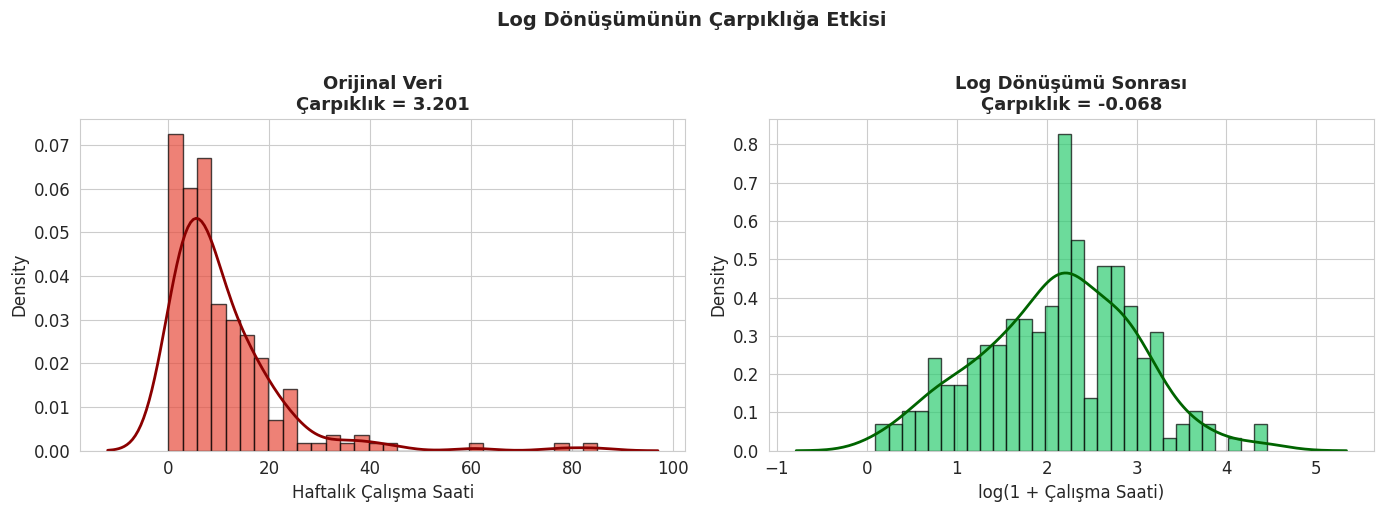

Orijinal çarpıklık : 3.201
Log sonrası çarpıklık: -0.068

💡 Log dönüşümü, sağa çarpık veriyi simetriğe yaklaştırdı.


In [ ]:
# 12.1 Log Dönüşümü
print('ÖZELLİK DÖNÜŞTÜRME')
print('=' * 70)
print('\n📍 Log Dönüşümü: Sağa çarpık veriyi normalleştirme')

orijinal = veri_imputed['Calısma_Saati_Haftalik']
log_donusum = np.log1p(orijinal)  # log(1+x) - sıfır değerler için güvenli

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orijinal
axes[0].hist(orijinal, bins=30, color='#e74c3c', edgecolor='black', alpha=0.7, density=True)
sns.kdeplot(orijinal, ax=axes[0], color='darkred', linewidth=2)
axes[0].set_title(f'Orijinal Veri\nÇarpıklık = {orijinal.skew():.3f}', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Haftalık Çalışma Saati')

# Log dönüşümü sonrası
axes[1].hist(log_donusum, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7, density=True)
sns.kdeplot(log_donusum, ax=axes[1], color='darkgreen', linewidth=2)
axes[1].set_title(f'Log Dönüşümü Sonrası\nÇarpıklık = {log_donusum.skew():.3f}', fontweight='bold', fontsize=13)
axes[1].set_xlabel('log(1 + Çalışma Saati)')

plt.suptitle('Log Dönüşümünün Çarpıklığa Etkisi', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Orijinal çarpıklık : {orijinal.skew():.3f}')
print(f'Log sonrası çarpıklık: {log_donusum.skew():.3f}')
print('\n💡 Log dönüşümü, sağa çarpık veriyi simetriğe yaklaştırdı.')

In [ ]:
# 12.2 Polinom Özellikleri
print('\n📍 Polinom Özellikleri: Doğrusal olmayan ilişkileri yakalama')
print('   x₁, x₂ → x₁, x₂, x₁², x₁·x₂, x₂²\n')

# Basit örnek
X_ornek = veri_imputed[['Not_Ortalamasi', 'Calısma_Saati_Haftalik']].head(5).values
print('Orijinal (ilk 5 satır):')
print(pd.DataFrame(X_ornek, columns=['Not', 'Çalışma']).to_string(index=False))

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_ornek)
poly_isimler = poly.get_feature_names_out(['Not', 'Çalışma'])

print(f'\nPolinom dönüşümü sonrası ({len(poly_isimler)} özellik):')
print(f'Yeni özellikler: {list(poly_isimler)}')
print(pd.DataFrame(X_poly, columns=poly_isimler).round(2).to_string(index=False))

print('\n💡 2 özellikten 5 özellik türetildi: x₁, x₂, x₁², x₁*x₂, x₂²')


📍 Polinom Özellikleri: Doğrusal olmayan ilişkileri yakalama
   x₁, x₂ → x₁, x₂, x₁², x₁·x₂, x₂²

Orijinal (ilk 5 satır):
 Not  Çalışma
2.66      0.5
3.92     15.2
2.83     17.6
2.24     13.9
2.02     16.1

Polinom dönüşümü sonrası (5 özellik):
Yeni özellikler: ['Not', 'Çalışma', 'Not^2', 'Not Çalışma', 'Çalışma^2']
 Not  Çalışma  Not^2  Not Çalışma  Çalışma^2
2.66      0.5   7.08         1.33       0.25
3.92     15.2  15.37        59.58     231.04
2.83     17.6   8.01        49.81     309.76
2.24     13.9   5.02        31.14     193.21
2.02     16.1   4.08        32.52     259.21

💡 2 özellikten 5 özellik türetildi: x₁, x₂, x₁², x₁*x₂, x₂²


In [ ]:
# 12.3 PCA - Temel Bileşen Analizi (Boyut İndirgeme)
print('\n📍 PCA: Temel Bileşen Analizi (Boyut İndirgeme)')
print('   4 boyutlu Iris verisini 2 boyuta indirgeme\n')

# Önce standartlaştırma (PCA için gerekli)
X_iris_scaled = StandardScaler().fit_transform(X_iris)

# PCA uygula
pca = PCA(n_components=4)  # Önce tüm bileşenleri hesapla
X_pca_full = pca.fit_transform(X_iris_scaled)

# Açıklanan varyans oranları
print('Her bileşenin açıkladığı varyans oranı:')
for i, (oran, kum_oran) in enumerate(zip(pca.explained_variance_ratio_, np.cumsum(pca.explained_variance_ratio_))):
    bar = '█' * int(oran * 50)
    print(f'  PC{i+1}: {oran:.4f} ({oran*100:.1f}%) | Kümülatif: {kum_oran*100:.1f}% {bar}')

# 2 bileşenle görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Açıklanan varyans
bilesenler = ['PC1', 'PC2', 'PC3', 'PC4']
varyans_oranlari = pca.explained_variance_ratio_ * 100
kumulatif = np.cumsum(varyans_oranlari)

axes[0].bar(bilesenler, varyans_oranlari, color='#3498db', edgecolor='black', alpha=0.7, label='Bireysel')
axes[0].plot(bilesenler, kumulatif, 'ro-', linewidth=2, markersize=8, label='Kümülatif')
axes[0].axhline(y=95, color='green', linestyle='--', linewidth=1.5, label='95% eşik')
axes[0].set_ylabel('Açıklanan Varyans (%)')
axes[0].set_title('PCA - Açıklanan Varyans Oranı', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)

for i, v in enumerate(varyans_oranlari):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# 2D PCA scatter plot
X_pca_2d = X_pca_full[:, :2]
for sinif, isim, renk in zip([0, 1, 2], iris.target_names, ['#e74c3c', '#2ecc71', '#3498db']):
    mask = y_iris == sinif
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c=renk, label=isim, alpha=0.7, edgecolor='gray', s=60)

axes[1].set_xlabel(f'PC1 ({varyans_oranlari[0]:.1f}% varyans)')
axes[1].set_ylabel(f'PC2 ({varyans_oranlari[1]:.1f}% varyans)')
axes[1].set_title('PCA ile 2 Boyutlu Projeksiyon\n(4 boyut → 2 boyut)', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f'\n💡 YORUM:')
print(f'   İlk 2 bileşen toplam varyansın %{kumulatif[1]:.1f}\'ini açıklıyor.')
print(f'   4 özellik yerine 2 bileşenle bile sınıflar büyük ölçüde ayrılabiliyor.')
print(f'   PCA, boyut indirgeme ve görselleştirme için güçlü bir araçtır.')

---
## 📋 Ders Özeti

Bu notebook boyunca aşağıdaki konuları öğrendik:

| # | Konu | Anahtar Kavram |
|---|------|----------------|
| 1 | Veri Nedir? | Veri → Bilgi → Bilgelik piramidi |
| 2 | Veri Türleri | Nitel (Nominal, Ordinal) ve Nicel (Kesikli, Sürekli) |
| 3 | Eksik Veri | MCAR/MAR/MNAR, silme vs doldurma yöntemleri |
| 4 | Aykırı Veri | IQR yöntemi, Z-skoru, Box Plot |
| 5 | Temel İstatistik | Ortalama, medyan, mod, varyans, std sapma |
| 6 | Çarpıklık/Basıklık | Dağılım şekli, Q-Q Plot yorumu |
| 7 | Dağılım Grafikleri | Histogram, KDE, Violin, Scatter, Pair Plot, Heatmap |
| 8 | Kütüphaneler | NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn |
| 9 | Scikit-learn vs DL | Klasik ML → Scikit-learn, Derin Öğrenme → TF/PyTorch |
| 10 | Veri Ön İşleme | Label/One-Hot Encoding, eksik veri doldurma |
| 11 | Normalizasyon | Min-Max, Z-Score, Robust Scaling |
| 12 | Özellik Seçimi | Varyans eşiği, SelectKBest, korelasyon |
| 13 | Özellik Dönüştürme | Log dönüşümü, Polinom özellikleri, PCA |

### Sonraki Ders: Sınıflandırma Algoritmaları (Karar Ağaçları, KNN, Naive Bayes)

---

**Hazırlayan:** Buket TOPTAŞ  
**Ders:** Veri Madenciliği - Ders 1